In [4]:
import requests
import json
import pandas as pd
import numpy as np
import os

In [5]:
codes = { "Prem": 21123, "Conf": 21136}
# codes = {"Van Aidans" : 39852}
exclude_id = 92234

In [6]:
def get_current_week():
    url = f"https://draft.premierleague.com/api/game"
    r = requests.get(url)
    json_raw = r.json()
    current_week = json_raw["current_event"]
    return current_week

current_week = get_current_week()
# current_week = 32
print(current_week)

SSLError: HTTPSConnectionPool(host='draft.premierleague.com', port=443): Max retries exceeded with url: /api/game (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1028)')))

In [ ]:
def get_league_table(league_code, exclude_id = exclude_id):
    url = f"https://draft.premierleague.com/api/league/{league_code}/details"
    r = requests.get(url)
    json_raw = r.json()
    
    mapping = pd.json_normalize(json_raw["league_entries"])[["entry_id", "entry_name", "id", "short_name", "player_first_name", "player_last_name"]]
    mapping["short_name"] = mapping["short_name"].str.upper()
    mapping["player_first_name"] = mapping["player_first_name"].str.capitalize()
    mapping["player_last_name"] = mapping["player_last_name"].str.capitalize()
    rename_map = {'player_first_name': 'first_name', 'player_last_name': 'last_name'}
    mapping = mapping.rename(columns=rename_map)
    # count_of_ids = mapping["id"].nunique()

    mapping = mapping[mapping["id"] != exclude_id]
    
    standings = pd.json_normalize(json_raw["standings"])[["league_entry", "event_total", "total", "rank", "last_rank"]]
    
    standings = standings.merge(mapping, left_on = "league_entry", right_on = "id", how = "inner")[["id", "entry_id", "entry_name", "short_name", "first_name", "last_name", "total", "event_total", "rank", "last_rank"]]
    standings['league_code'] = league_code
    standings.rename(columns={'event_total': 'gameweek_points'}, inplace=True)
    return standings#, count_of_ids

In [ ]:
league_table = pd.concat([get_league_table(codes["Prem"]),get_league_table(codes["Conf"])])
# league_table = get_league_table(codes["Prem"])
# invert the dictionary to map code to name
code_to_name = {v: k for k, v in codes.items()}
name_to_code = {k: v for k, v in codes.items()}

# assuming league_table is your dataframe and has a column 'league_code'
league_table['league_code'] = league_table['league_code'].replace(code_to_name)
league_table = league_table.sort_values(by=['league_code', 'rank'], ascending=[False, True])
league_table['name'] = league_table['first_name'] + ' ' + league_table['last_name']
league_table


,id,entry_id,entry_name,short_name,first_name,last_name,total,gameweek_points,rank,last_rank,league_code,name
0,97971,100781,Ahmed** Diallooooo,TS,Tom,Shiel,1650,87,1,1,Prem,Tom Shiel
1,93420,96259,Premiership Cru,LB,Luc,Baldwin,1539,53,2,2,Prem,Luc Baldwin
2,151694,154251,No Salah No Problem*,JP,Joe,Payne,1535,65,3,3,Prem,Joe Payne
3,193988,196213,Slots of Change,AN,Andrew,Newbery,1419,72,4,5,Prem,Andrew Newbery
4,175163,177570,While True: Draft,MN,Mike,Nelson,1408,44,5,4,Prem,Mike Nelson
5,216742,218704,Boom Xhakaluca,LD,Luc,Durandt,1358,74,6,6,Prem,Luc Durandt
0,199375,201562,Rope-a-pope*^,CR,Chris,Roper,1577,64,1,1,Conf,Chris Roper
1,257759,259062,PiroePerriChicken,AC,Alex,Clark,1550,75,2,2,Conf,Alex Clark
2,92289,95131,Astericky Martin *,PV,Peter,Vickers,1507,81,3,3,Conf,Peter Vickers
3,106847,109621,Waiver & Out,HC,Henry,Cartmell,1480,73,4,5,Conf,Henry Cartmell


In [ ]:
def get_players_all_time():
    url = f"https://draft.premierleague.com/api/bootstrap-static"
    r = requests.get(url)
    json_raw = r.json()
    
    players = pd.json_normalize(json_raw["elements"])[["id" ,"web_name", "element_type", "team", "total_points", "goals_scored", "assists", "bonus", "clean_sheets", "minutes", "draft_rank"]]
    positions = pd.json_normalize(json_raw["element_types"])[["id", "singular_name_short"]]
    positions.columns = ["element_type", "position"]
    players = players.merge(positions, on = "element_type", how = "inner")
    teams = pd.json_normalize(json_raw["teams"])[["id", "short_name"]]
    teams.columns = ["team", "team_name"]
    players = players.merge(teams, on = "team", how = "inner")
    players = players[["id", "web_name", "team", "team_name", "position", "total_points", "goals_scored", "assists", "bonus", "clean_sheets", "minutes", "draft_rank"]]
    return players, teams

all_players, teams = get_players_all_time()

In [ ]:
teams

,team,team_name
0,1,ARS
1,2,AVL
2,3,BUR
3,4,BOU
4,5,BRE
5,6,BHA
6,7,CHE
7,8,CRY
8,9,EVE
9,10,FUL


In [ ]:
def get_players_all_time_fantasy():
    url = f"https://fantasy.premierleague.com/api/bootstrap-static"
    r = requests.get(url)
    json_raw = r.json()
    
    players = pd.json_normalize(json_raw["elements"])[["id", "selected_by_percent", "now_cost"]]
    teams_details = pd.json_normalize(json_raw["teams"])[["id", "short_name", "strength", "strength_overall_home", "strength_overall_away", "strength_attack_home", "strength_attack_away", "strength_defence_home", "strength_defence_away"]]
    # players = pd.json_normalize(json_raw["elements"])[["id" ,"web_name", "now_cost", "select_by_percent"]]
    return players, teams_details

fantasy_players, fantasy_teams_details = get_players_all_time_fantasy()
fantasy_players['now_cost'] = fantasy_players['now_cost'] / 10  # convert to pounds

all_players = all_players.merge(fantasy_players, on = "id", how = "inner")

fantasy_teams_details

,id,short_name,strength,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away
0,1,ARS,5,1305,1365,1340,1390,1270,1340
1,2,AVL,3,1140,1220,1100,1230,1180,1210
2,3,BUR,2,975,1080,910,1070,1040,1090
3,4,BOU,3,1140,1215,1060,1210,1220,1220
4,5,BRE,3,1150,1215,1130,1150,1170,1280
5,6,BHA,3,1160,1230,1140,1200,1180,1260
6,7,CHE,4,1205,1210,1140,1150,1270,1270
7,8,CRY,3,1165,1175,1150,1170,1180,1180
8,9,EVE,3,1135,1180,1140,1160,1130,1200
9,10,FUL,3,1105,1200,1090,1170,1120,1230


In [ ]:
def get_fixtures(teams):
    url = f"https://fantasy.premierleague.com/api/fixtures/"
    r = requests.get(url)
    json_raw = r.json()
    
    fixtures = pd.json_normalize(json_raw)[["event", "team_a", "team_h", "team_a_score", "team_h_score", "team_a_difficulty", "team_h_difficulty", "kickoff_time"]]
    fixtures["team_h_score"] = fixtures["team_h_score"].fillna(0).astype(int)
    fixtures["team_a_score"] = fixtures["team_a_score"].fillna(0).astype(int)

    team_map = teams.set_index("team")["team_name"]

    fixtures2 = fixtures.assign(
        team_a=lambda d: d["team_a"].map(team_map),
        team_h=lambda d: d["team_h"].map(team_map),
        kickoff_time=lambda d: pd.to_datetime(d["kickoff_time"], utc=True, errors="coerce"),
    )

    # --- per-match rows (per team) ---
    home = (
        fixtures2.rename(columns={"event": "gameweek"})
        .assign(
            team=lambda d: d["team_h"],
            opposition=lambda d: d["team_a"],
            home_away="H",
            team_score=lambda d: d["team_h_score"],
            opposition_score=lambda d: d["team_a_score"],
            team_difficulty=lambda d: d["team_h_difficulty"],
            opposition_difficulty=lambda d: d["team_a_difficulty"],
        )[
            [
                "gameweek","kickoff_time","team","opposition","home_away",
                "team_score","opposition_score","team_difficulty","opposition_difficulty",
            ]
        ]
    )

    away = (
        fixtures2.rename(columns={"event": "gameweek"})
        .assign(
            team=lambda d: d["team_a"],
            opposition=lambda d: d["team_h"],
            home_away="A",
            team_score=lambda d: d["team_a_score"],
            opposition_score=lambda d: d["team_h_score"],
            team_difficulty=lambda d: d["team_a_difficulty"],
            opposition_difficulty=lambda d: d["team_h_difficulty"],
        )[
            [
                "gameweek","kickoff_time","team","opposition","home_away",
                "team_score","opposition_score","team_difficulty","opposition_difficulty",
            ]
        ]
    )

    team_gw_matches = (
        pd.concat([home, away], ignore_index=True)
        .sort_values(["gameweek", "team", "kickoff_time"])
        .reset_index(drop=True)
    )

    # --- ordered concatenation helpers (preserve order; optional de-dupe) ---
    def ordered_join(s, sep="-", dedupe=True):
        items = [str(x) for x in s.tolist()]
        if not dedupe:
            return sep.join(items)
        seen, out = set(), []
        for x in items:
            if x not in seen:
                seen.add(x)
                out.append(x)
        return sep.join(out)

    # --- aggregate to 1 row per (gameweek, team), doubles handled ---
    team_gw = (
        team_gw_matches
        .groupby(["gameweek", "team"], as_index=False)
        .agg(
            gameweek_matches=("opposition", "size"),
            opposition=("opposition", lambda s: ordered_join(s, sep="-", dedupe=True)),  # e.g. ARS-LIV
            home_away=("home_away", lambda s: ordered_join(s, sep="", dedupe=False)),   # e.g. HA
            team_score=("team_score", "mean"),
            opposition_score=("opposition_score", "mean"),
            team_difficulty=("team_difficulty", "mean"),
            opposition_difficulty=("opposition_difficulty", "mean"),
            kickoff_time_first=("kickoff_time", "min"),  # optional: useful for sorting/display
        )
        .sort_values(["gameweek", "team"])
        .reset_index(drop=True)
    )
    return fixtures2, team_gw

fixtures, fixtures_by_team = get_fixtures(teams)
print(fixtures)
fixtures_by_team

     event team_a team_h  team_a_score  team_h_score  team_a_difficulty  \
0      NaN    CRY    MCI             0             0                  5   
1      1.0    BOU    LIV             2             4                  4   
2      1.0    NEW    AVL             0             0                  4   
3      1.0    FUL    BHA             1             1                  4   
4      1.0    BUR    TOT             0             3                  2   
..     ...    ...    ...           ...           ...                ...   
375   38.0    AVL    MCI             0             0                  5   
376   38.0    BOU    NFO             0             0                  3   
377   38.0    EVE    TOT             0             0                  2   
378   38.0    CHE    SUN             0             0                  3   
379   38.0    LEE    WHU             0             0                  2   

     team_h_difficulty              kickoff_time  
0                    3                       NaT

,gameweek,team,gameweek_matches,opposition,home_away,team_score,opposition_score,team_difficulty,opposition_difficulty,kickoff_time_first
0,1.0,ARS,1,MUN,A,1.0,0.0,4.0,4.0,2025-08-17 15:30:00+00:00
1,1.0,AVL,1,NEW,H,0.0,0.0,3.0,4.0,2025-08-16 11:30:00+00:00
2,1.0,BHA,1,FUL,H,1.0,1.0,3.0,4.0,2025-08-16 14:00:00+00:00
3,1.0,BOU,1,LIV,A,2.0,4.0,4.0,3.0,2025-08-15 19:00:00+00:00
4,1.0,BRE,1,NFO,A,1.0,3.0,3.0,3.0,2025-08-17 13:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...
745,38.0,NFO,1,BOU,H,0.0,0.0,3.0,3.0,2026-05-24 15:00:00+00:00
746,38.0,SUN,1,CHE,H,0.0,0.0,3.0,3.0,2026-05-24 15:00:00+00:00
747,38.0,TOT,1,EVE,H,0.0,0.0,3.0,2.0,2026-05-24 15:00:00+00:00
748,38.0,WHU,1,LEE,H,0.0,0.0,2.0,2.0,2026-05-24 15:00:00+00:00


In [ ]:
fixtures[fixtures["event"] == current_week]

,event,team_a,team_h,team_a_score,team_h_score,team_a_difficulty,team_h_difficulty,kickoff_time
320,33.0,FUL,BRE,0,0,3,3,2026-04-18 11:30:00+00:00
321,33.0,WOL,LEE,0,3,3,1,2026-04-18 14:00:00+00:00
322,33.0,BOU,NEW,2,1,3,3,2026-04-18 14:00:00+00:00
323,33.0,BHA,TOT,2,2,2,3,2026-04-18 16:30:00+00:00
324,33.0,MUN,CHE,1,0,3,3,2026-04-18 19:00:00+00:00
325,33.0,SUN,AVL,3,4,4,2,2026-04-19 13:00:00+00:00
326,33.0,LIV,EVE,2,1,3,3,2026-04-19 13:00:00+00:00
327,33.0,BUR,NFO,1,4,3,1,2026-04-19 13:00:00+00:00
328,33.0,ARS,MCI,1,2,5,4,2026-04-19 15:30:00+00:00
329,33.0,WHU,CRY,0,0,3,2,2026-04-20 19:00:00+00:00


In [ ]:
def get_draft_picks(league_code, all_players):
    table = get_league_table(league_code)
    url = f"https://draft.premierleague.com/api/draft/{league_code}/choices"
    r = requests.get(url)
    json_raw = r.json()
    
    draft_picks = pd.json_normalize(json_raw["choices"])
    status = pd.json_normalize(json_raw["element_status"])
    
    draft_picks = draft_picks.merge(all_players, left_on = 'element', right_on =  'id', how = 'inner')
    draft_picks = draft_picks.merge(table, left_on = 'entry', right_on = 'entry_id', how = 'inner')
    # draft_picks = draft_picks[["element","short_name", "index", "pick", "web_name", "total_points", "league_code", "position", "draft_rank", "now_cost", "selected_by_percent", "team", "team_name", "first_name", "last_name"]]
    draft_picks = draft_picks[["element","short_name", "index", "pick", "web_name", "league_code", "position", "draft_rank", "now_cost", "selected_by_percent", "team", "team_name", "first_name", "last_name"]]
    return draft_picks, status

draft_picks = pd.concat([get_draft_picks(codes["Prem"], all_players)[0], get_draft_picks(codes["Conf"], all_players)[0]])
# draft_picks = get_draft_picks(codes["Prem"], all_players)[0]
draft_picks['league_code'] = draft_picks['league_code'].replace(code_to_name)

draft_picks.sort_values(['league_code', 'index'], ascending = [False, True])
draft_picks['index'] = np.where(draft_picks['league_code'] == 'Prem', range(1, len(draft_picks) + 1), draft_picks['index']).astype(int)
draft_picks['round'] = ((draft_picks['index']-1) // 6) + 1
draft_picks['index'] = draft_picks['index'].astype(int)
draft_picks['round'] = draft_picks['round'].astype(int)
draft_picks

,element,short_name,index,pick,web_name,league_code,position,draft_rank,now_cost,selected_by_percent,team,team_name,first_name,last_name,round
0,381,LD,1,1,M.Salah,Prem,MID,1,14.0,15.9,12,LIV,Luc,Durandt,1
1,430,TS,2,2,Haaland,Prem,FWD,2,14.5,56.9,13,MCI,Tom,Shiel,1
2,499,JP,3,3,Isak,Prem,FWD,4,10.3,4.1,12,LIV,Joe,Payne,1
3,235,MN,4,4,Palmer,Prem,MID,3,10.5,16.9,7,CHE,Mike,Nelson,1
4,16,LB,5,6,Saka,Prem,MID,5,9.8,7.0,1,ARS,Luc,Baldwin,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,101,BP,86,2,Kelleher,Conf,GKP,400,4.8,12.8,5,BRE,Billy,Phillips,15
86,502,CR,87,3,Sels,Conf,GKP,249,4.6,5.0,16,NFO,Chris,Roper,15
87,292,IR,88,4,Mykolenko,Conf,DEF,260,4.9,0.7,9,EVE,Ivan,Rutherford,15
88,253,PV,89,5,Henderson,Conf,GKP,266,5.1,8.0,8,CRY,Peter,Vickers,15


In [ ]:
# def calc_optimal_points(squad, best = True):
#     # Step 1: Strictly select mandatory positions
#     if best:
#         picked_gk = squad[squad["position"] == "GKP"].nlargest(1, "total_points")
#         picked_defs = squad[squad["position"] == "DEF"].nlargest(3, "total_points")
#         picked_mids = squad[squad["position"] == "MID"].nlargest(3, "total_points")
#         picked_fwd = squad[squad["position"] == "FWD"].nlargest(1, "total_points")
#     else:
#         picked_gk = squad[squad["position"] == "GKP"].nsmallest(1, "total_points")
#         picked_defs = squad[squad["position"] == "DEF"].nsmallest(3, "total_points")
#         picked_mids = squad[squad["position"] == "MID"].nsmallest(3, "total_points")
#         picked_fwd = squad[squad["position"] == "FWD"].nsmallest(1, "total_points")
    
#     # Combine mandatory players
#     mandatory_players = pd.concat([picked_gk, picked_defs, picked_mids, picked_fwd])
    
#     # Step 2: Exclude mandatory players and second GK, and find 3 additional best players
#     remaining_players = squad.drop(mandatory_players.index)
#     remaining_players = remaining_players[remaining_players["position"] != "GKP"]
#     if best:
#         additional_players = remaining_players.nlargest(3, "total_points")
#     else:
#         additional_players = remaining_players.nsmallest(3, "total_points")
    
#     # Final starting 11
#     starting_11 = pd.concat([mandatory_players, additional_players])
    
#     # Step 3: Assign optimal points
#     if best:
#         column_name = "optimal_points"
#     else:
#         column_name = "suboptimal_points"
        
#     squad[column_name] = squad["total_points"]
#     squad.loc[~squad.index.isin(starting_11.index), column_name] = 0
#     squad[column_name] = pd.to_numeric(squad[column_name])
#     return squad
    
# def get_weekly_summary(league_code, current_week, all_players, draft_picks):
#     table = get_league_table(league_code)
#     all_picks = pd.DataFrame(columns = ['element', 'position', 'gameweek', 'short_name', 'league_code', 'originally_starting'])
#     all_points = pd.DataFrame(columns = ['id', 'total_points', 'gameweek'])
#     # all_fixtures = pd.DataFrame(columns = ['team_a', 'team_h', 'gameweek'])
#     for gameweek in range(current_week):
# #         print(gameweek)
#         for entry_id, name in zip(table["entry_id"], table["short_name"]):
# #             print(name)
#             url = f"https://draft.premierleague.com/api/entry/{entry_id}/event/{gameweek+1}"
#             r = requests.get(url)
#             json_raw = r.json()
#             picks = pd.json_normalize(json_raw["picks"])[['element', 'position']]
#             picks['gameweek'] = gameweek + 1
#             picks['short_name'] = name
#             picks['league_code'] = league_code
#             picks['originally_starting'] = np.where(picks['position'] <= 11, 1, 0)
#             subs = pd.json_normalize(json_raw["subs"], errors = 'ignore')
#             if len(subs) > 0:
#                 picks.loc[picks['element'].isin(subs['element_in']), 'originally_starting'] = 0
#                 picks.loc[picks['element'].isin(subs['element_out']), 'originally_starting'] = 1
#             all_picks = pd.concat([all_picks, picks], ignore_index = True)
#         url = f"https://draft.premierleague.com/api/event/{gameweek+1}/live"
#         r = requests.get(url)
#         json_raw = r.json()
#         elements = json_raw.get("elements", {})
#         rows = [
#             {"id": int(elem_id), "total_points": details["stats"].get("total_points", 0)}
#             for elem_id, details in elements.items()
#         ]
#         points = pd.DataFrame(rows)
#         points['gameweek'] = gameweek+1
#         all_points = pd.concat([all_points, points], ignore_index = True)
# #         fixtures = json_raw.get("fixtures", {})
# #         fixtures = pd.json_normalize(json_raw["fixtures"])[['team_a', 'team_h']]
# #         fixtures.rename(columns={'team_a': 'team_player', 'team_h': 'team_opponent'}, inplace = True)
# #         fixtures['gameweek'] = gameweek+1
# #         fixtures['home_or_away'] = 'away'
# #         fixtures_alt = fixtures.rename(columns={'team_opponent': 'team_player', 'team_player': 'team_opponent'})
# #         fixtures_alt['home_or_away'] = 'home'
# #         fixtures = pd.concat([fixtures, fixtures_alt], ignore_index = True)
# #         all_fixtures = pd.concat([all_fixtures, fixtures], ignore_index = True)
#     output = all_picks.merge(all_points, left_on = ['element', 'gameweek'], right_on = ['id', 'gameweek'], how = 'inner')
#     output['total_points'] = pd.to_numeric(output['total_points'])
#     output['points_before_auto_subs'] = np.where(output['originally_starting'] == 1, output['total_points'], 0)
#     player_total_points = all_points.groupby('id')['total_points'].sum().reset_index().rename(columns={'total_points': 'player_total_points'})
#     output = output.merge(player_total_points.rename(columns={'id': 'element'}), on = 'element', how = 'left').rename(columns={'total_points_y': 'player_total_points'})
#     # player_details = all_players[['id', 'web_name', 'position', 'team', 'team_name', 'total_points']].rename(columns={'id': 'element', 'team': 'team_id', 'total_points': 'player_total_points'})
#     player_details = all_players[['id', 'web_name', 'position', 'team', 'team_name']].rename(columns={'id': 'element', 'team': 'team_id'})
#     player_details = player_details.merge(draft_picks[draft_picks['league_code'].replace(name_to_code) == league_code][["element", "short_name", "index"]], on = ["element"], how = 'left')
#     player_details = player_details.rename(columns={'short_name': 'drafter_name', 'index': 'draft_index'})
#     player_details['drafter_name'] = player_details['drafter_name'].fillna('Not Originally Drafted')

#     output.rename(columns={'position': 'place'}, inplace = True)
#     output = output.merge(player_details, on = 'element')
# #     output = output.merge(all_fixtures, left_on = ['gameweek', 'team_id'], right_on = ['gameweek', 'team_player'])
#     output['points_scored'] = np.where(output['place'] <= 11, output['total_points'], 0)
#     output = output.merge(draft_picks[["element", "short_name", "index", "round"]], on = ["element", "short_name"], how = 'left')
#     output['in_original_draft'] = np.where(output['index'].isna(), 0, 1)
#     #output['optimal_points'] = 0
#     optimal_point_table = pd.DataFrame(columns = ['element', 'short_name', 'gameweek', 'optimal_points', 'suboptimal_points'])
#     for name in output['short_name'].unique():
#         for week in range(current_week):
#             squad_table = output[(output['short_name'] == name) & (output['gameweek'] == week + 1)]
#             squad_table = calc_optimal_points(squad_table)
#             squad_table = calc_optimal_points(squad_table, best = False)
#             optimal_point_table = pd.concat([optimal_point_table, squad_table[['element', 'short_name', 'gameweek', 'optimal_points', 'suboptimal_points']]])
#     optimal_point_table['optimal_points'] = pd.to_numeric(optimal_point_table['optimal_points'])
#     optimal_point_table['suboptimal_points'] = pd.to_numeric(optimal_point_table['suboptimal_points'])
#     output = output.merge(optimal_point_table)
#     output = output.merge(table[['league_code', 'short_name', 'total']], on = ['league_code', 'short_name'])
#     output['points_scored_pct'] = output['points_scored'] / output['total']
#     output[['index', 'round', 'points_scored', 'player_total_points']] = output[['index', 'round', 'points_scored', 'player_total_points']].fillna(0).astype(int)
#     output = output.sort_values(by = ['league_code', 'short_name', 'id', 'gameweek'])
#     output['points_scored_cumulative'] = output.groupby(['league_code', 'short_name', 'id'])['points_scored'].cumsum()

#     all_points = all_points.sort_values(['gameweek', 'total_points'], ascending = [True, False])
#     all_points['rank_in_week'] = all_points.groupby('gameweek')['total_points'].rank(method='min', ascending=False).astype(int)
#     all_points = all_points.merge(output[['element', 'gameweek', 'short_name', 'place']], left_on = ['id', 'gameweek'], right_on = ['element', 'gameweek'], how = 'left')
#     all_points['short_name'] = all_points['short_name'].fillna('Not Drafted')
#     all_points['isBenched'] = np.where(all_points['place'] > 11, 1, 0)
#     all_points['short_name'] = np.where(all_points['isBenched'] == 1, all_points['short_name'] + ' (Benched)', all_points['short_name'])
#     all_points['league_code'] = league_code
#     all_points = all_points.merge(player_details, left_on = 'id', right_on = 'element', how = 'left')
#     return output, all_points
# #             subs = pd.json_normalize(json_raw["subs"])

# conf_weekly_summary, player_points_weekly_conf = get_weekly_summary(codes['Conf'], current_week, all_players, draft_picks)
# prem_weekly_summary, player_points_weekly_prem = get_weekly_summary(codes['Prem'], current_week, all_players, draft_picks)
# weekly_summary = pd.concat([conf_weekly_summary, prem_weekly_summary])
# player_points_weekly = pd.concat([player_points_weekly_conf, player_points_weekly_prem])
# # weekly_summary, points = get_weekly_summary(codes['Conf'], current_week, all_players)
# weekly_summary['league_code'] = weekly_summary['league_code'].replace(code_to_name)
# player_points_weekly['league_code'] = player_points_weekly['league_code'].replace(code_to_name)

# total_player_points = player_points_weekly.groupby(['league_code', 'short_name', 'id'])['total_points'].sum().reset_index()
# draft_picks = draft_picks.merge(total_player_points, left_on = ['league_code', 'short_name', 'element'], right_on = ['league_code', 'short_name', 'id'], how = 'left')

# # weekly_summary.to_csv('Weekly Summary.csv')
# weekly_summary

In [ ]:
import pandas as pd
from itertools import combinations, product
from math import comb

def _selection_outcomes_best(df: pd.DataFrame, k: int):
    """
    Select k highest total_points with uniform random tie-break at the cutoff.
    Returns list of (selected_index_tuple, probability).
    """
    if k <= 0 or df.empty:
        return [(tuple(), 1.0)]
    n = len(df)
    if k >= n:
        return [(tuple(df.index.tolist()), 1.0)]

    pts = pd.to_numeric(df["total_points"])
    cutoff = pts.sort_values(ascending=False).iloc[k - 1]

    above = df[pts > cutoff]
    tied  = df[pts == cutoff]

    need = k - len(above)
    above_idx = tuple(above.index.tolist())

    if need <= 0:
        return [(above_idx, 1.0)]

    tied_idx = tied.index.tolist()
    t = len(tied_idx)

    if need >= t:
        return [(tuple(list(above_idx) + tied_idx), 1.0)]

    denom = comb(t, need)
    return [
        (tuple(list(above_idx) + list(chosen)), 1.0 / denom)
        for chosen in combinations(tied_idx, need)
    ]


def calc_optimal_points(squad: pd.DataFrame):
    """
    Constraints:
      - exactly 1 GKP
      - at least 3 DEF (you force 3 DEF mandatory)
      - at least 1 FWD (you force 1 FWD mandatory)
      - at least 2 MID overall
    After mandatory (1 GKP, 3 DEF, 1 FWD), choose 6 more outfielders
    maximizing total_points while meeting the MID minimum.
    Fractional weights reflect uniform choice among tied-optimal solutions.
    """
    squad = squad.copy()
    pts = pd.to_numeric(squad["total_points"])

    # Mandatory selection outcomes
    gk_out  = _selection_outcomes_best(squad[squad["position"] == "GKP"], 1)
    def_out = _selection_outcomes_best(squad[squad["position"] == "DEF"], 3)
    fwd_out = _selection_outcomes_best(squad[squad["position"] == "FWD"], 1)

    w = pd.Series(0.0, index=squad.index)

    for (gk_sel, pgk), (def_sel, pdef), (fwd_sel, pfwd) in product(gk_out, def_out, fwd_out):
        p_mand = pgk * pdef * pfwd
        mand_idx = set(gk_sel) | set(def_sel) | set(fwd_sel)

        # mandatory always included for this branch
        for i in mand_idx:
            w.loc[i] += p_mand

        # remaining pool for the extra 6: outfield only, excluding mandatory
        remaining = squad.drop(list(mand_idx))
        remaining = remaining[remaining["position"] != "GKP"]

        # how many mids still required to reach min 2 overall?
        mids_in_mand = sum(squad.loc[list(mand_idx), "position"] == "MID")
        mids_needed = max(0, 2 - mids_in_mand)

        rem_idx = remaining.index.tolist()
        if len(rem_idx) < 6:
            # should not happen in a valid 15-man squad, but guard anyway
            continue

        best_total = None
        best_sets = []

        # enumerate all size-6 sets, filter by MID requirement
        for comb_idx in combinations(rem_idx, 6):
            if mids_needed > 0:
                mid_count = sum(remaining.loc[list(comb_idx), "position"] == "MID")
                if mid_count < mids_needed:
                    continue

            total = float(pts.loc[list(comb_idx)].sum())
            if (best_total is None) or (total > best_total):
                best_total = total
                best_sets = [comb_idx]
            elif total == best_total:
                best_sets.append(comb_idx)

        if not best_sets:
            # In case something weird happens, fall back to top 6 (no extra constraint)
            best_sets = [tuple(remaining.nlargest(6, "total_points").index.tolist())]

        # share probability uniformly across tied-optimal sets
        share = p_mand / len(best_sets)
        for s in best_sets:
            for i in s:
                w.loc[i] += share

    squad["optimal_weight"] = w
    squad["optimal_points"] = pts * squad["optimal_weight"]
    return squad

def get_weekly_summary(league_code, current_week, all_players, draft_picks):
    table = get_league_table(league_code)
    all_picks = pd.DataFrame(columns = ['element', 'position', 'gameweek', 'short_name', 'league_code', 'originally_starting'])
    all_points = pd.DataFrame(columns = ['id', 'total_points', 'gameweek'])
    # all_fixtures = pd.DataFrame(columns = ['team_a', 'team_h', 'gameweek'])
    for gameweek in range(current_week):
#         print(gameweek)
        for entry_id, name in zip(table["entry_id"], table["short_name"]):
#             print(name)
            url = f"https://draft.premierleague.com/api/entry/{entry_id}/event/{gameweek+1}"
            r = requests.get(url)
            json_raw = r.json()
            picks = pd.json_normalize(json_raw["picks"])[['element', 'position']]
            picks['gameweek'] = gameweek + 1
            picks['short_name'] = name
            picks['league_code'] = league_code
            picks['originally_starting'] = np.where(picks['position'] <= 11, 1, 0)
            subs = pd.json_normalize(json_raw["subs"], errors = 'ignore')
            if len(subs) > 0:
                picks.loc[picks['element'].isin(subs['element_in']), 'originally_starting'] = 0
                picks.loc[picks['element'].isin(subs['element_out']), 'originally_starting'] = 1
            all_picks = pd.concat([all_picks, picks], ignore_index = True)
        url = f"https://draft.premierleague.com/api/event/{gameweek+1}/live"
        r = requests.get(url)
        json_raw = r.json()
        elements = json_raw.get("elements", {})
        rows = [
            {"id": int(elem_id), "total_points": details["stats"].get("total_points", 0)}
            for elem_id, details in elements.items()
        ]
        points = pd.DataFrame(rows)
        points['gameweek'] = gameweek+1
        all_points = pd.concat([all_points, points], ignore_index = True)
#         fixtures = json_raw.get("fixtures", {})
#         fixtures = pd.json_normalize(json_raw["fixtures"])[['team_a', 'team_h']]
#         fixtures.rename(columns={'team_a': 'team_player', 'team_h': 'team_opponent'}, inplace = True)
#         fixtures['gameweek'] = gameweek+1
#         fixtures['home_or_away'] = 'away'
#         fixtures_alt = fixtures.rename(columns={'team_opponent': 'team_player', 'team_player': 'team_opponent'})
#         fixtures_alt['home_or_away'] = 'home'
#         fixtures = pd.concat([fixtures, fixtures_alt], ignore_index = True)
#         all_fixtures = pd.concat([all_fixtures, fixtures], ignore_index = True)
    output = all_picks.merge(all_points, left_on = ['element', 'gameweek'], right_on = ['id', 'gameweek'], how = 'inner')
    output['total_points'] = pd.to_numeric(output['total_points'])
    output['points_before_auto_subs'] = np.where(output['originally_starting'] == 1, output['total_points'], 0)
    player_total_points = all_points.groupby('id')['total_points'].sum().reset_index().rename(columns={'total_points': 'player_total_points'})
    output = output.merge(player_total_points.rename(columns={'id': 'element'}), on = 'element', how = 'left').rename(columns={'total_points_y': 'player_total_points'})
    # player_details = all_players[['id', 'web_name', 'position', 'team', 'team_name', 'total_points']].rename(columns={'id': 'element', 'team': 'team_id', 'total_points': 'player_total_points'})
    player_details = all_players[['id', 'web_name', 'position', 'team', 'team_name']].rename(columns={'id': 'element', 'team': 'team_id'})
    player_details = player_details.merge(draft_picks[draft_picks['league_code'].replace(name_to_code) == league_code][["element", "short_name", "index"]], on = ["element"], how = 'left')
    player_details = player_details.rename(columns={'short_name': 'drafter_name', 'index': 'draft_index'})
    player_details['drafter_name'] = player_details['drafter_name'].fillna('Not Originally Drafted')

    output.rename(columns={'position': 'place'}, inplace = True)
    output = output.merge(player_details, on = 'element')
#     output = output.merge(all_fixtures, left_on = ['gameweek', 'team_id'], right_on = ['gameweek', 'team_player'])
    output['points_scored'] = np.where(output['place'] <= 11, output['total_points'], 0)
    output = output.merge(draft_picks[["element", "short_name", "index", "round"]], on = ["element", "short_name"], how = 'left')
    output['in_original_draft'] = np.where(output['index'].isna(), 0, 1)
    #output['optimal_points'] = 0
    optimal_point_table = pd.DataFrame(columns = ['element', 'short_name', 'gameweek', 'optimal_points'])
    for name in output['short_name'].unique():
        for week in range(current_week):
            squad_table = output[(output['short_name'] == name) & (output['gameweek'] == week + 1)]
            squad_table = calc_optimal_points(squad_table)
            # squad_table = calc_optimal_points_fractional_exact(squad_table, best = False)
            optimal_point_table = pd.concat([optimal_point_table, squad_table[['element', 'short_name', 'gameweek', 'optimal_points']]])
    optimal_point_table['optimal_points'] = pd.to_numeric(optimal_point_table['optimal_points'])
    output = output.merge(optimal_point_table)
    output = output.merge(table[['league_code', 'short_name', 'total']], on = ['league_code', 'short_name'])
    output['points_scored_pct'] = output['points_scored'] / output['total']
    output[['index', 'round', 'points_scored', 'player_total_points']] = output[['index', 'round', 'points_scored', 'player_total_points']].fillna(0).astype(int)
    output = output.sort_values(by = ['league_code', 'short_name', 'id', 'gameweek'])
    output['points_scored_cumulative'] = output.groupby(['league_code', 'short_name', 'id'])['points_scored'].cumsum()

    all_points = all_points.sort_values(['gameweek', 'total_points'], ascending = [True, False])
    all_points['rank_in_week'] = all_points.groupby('gameweek')['total_points'].rank(method='min', ascending=False).astype(int)
    all_points = all_points.merge(output[['element', 'gameweek', 'short_name', 'place']], left_on = ['id', 'gameweek'], right_on = ['element', 'gameweek'], how = 'left')
    all_points['short_name'] = all_points['short_name'].fillna('Not Drafted')
    all_points['isBenched'] = np.where(all_points['place'] > 11, 1, 0)
    all_points['short_name'] = np.where(all_points['isBenched'] == 1, all_points['short_name'] + ' (Benched)', all_points['short_name'])
    all_points['league_code'] = league_code
    all_points = all_points.merge(player_details, left_on = 'id', right_on = 'element', how = 'left')
    return output, all_points
#             subs = pd.json_normalize(json_raw["subs"])

conf_weekly_summary, player_points_weekly_conf = get_weekly_summary(codes['Conf'], current_week, all_players, draft_picks)
prem_weekly_summary, player_points_weekly_prem = get_weekly_summary(codes['Prem'], current_week, all_players, draft_picks)
weekly_summary = pd.concat([conf_weekly_summary, prem_weekly_summary])
player_points_weekly = pd.concat([player_points_weekly_conf, player_points_weekly_prem])
# weekly_summary, points = get_weekly_summary(codes['Conf'], current_week, all_players)
weekly_summary['league_code'] = weekly_summary['league_code'].replace(code_to_name)
player_points_weekly['league_code'] = player_points_weekly['league_code'].replace(code_to_name)

total_player_points = player_points_weekly.groupby(['league_code', 'short_name', 'id'])['total_points'].sum().reset_index()
draft_picks = draft_picks.merge(total_player_points, left_on = ['league_code', 'short_name', 'element'], right_on = ['league_code', 'short_name', 'id'], how = 'left')

player_points_weekly = player_points_weekly.merge(fixtures_by_team, left_on = ['gameweek', 'team_name'], right_on = ['gameweek', 'team'], how = 'left')
weekly_summary = weekly_summary.merge(fixtures_by_team, left_on = ['gameweek', 'team_name'], right_on = ['gameweek', 'team'], how = 'left')

# weekly_summary.to_csv('Weekly Summary.csv')
weekly_summary

C:\Users\MikeNelson\AppData\Local\Temp\ipykernel_4120\3046251634.py:163: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  player_details = player_details.merge(draft_picks[draft_picks['league_code'].replace(name_to_code) == league_code][["element", "short_name", "index"]], on = ["element"], how = 'left')
C:\Users\MikeNelson\AppData\Local\Temp\ipykernel_4120\3046251634.py:180: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  optimal_point_table = pd.concat([optimal_point_table, squad_table[['element', 'short_name', 'gam

,element,place,gameweek,short_name,league_code,originally_starting,id,total_points,points_before_auto_subs,player_total_points,...,points_scored_cumulative,team,gameweek_matches,opposition,home_away,team_score,opposition_score,team_difficulty,opposition_difficulty,kickoff_time_first
0,1,1,1,AC,Conf,1,1,10,10,131,...,10,ARS,1.0,MUN,A,1.0,0.0,4.0,4.0,2025-08-17 15:30:00+00:00
1,1,1,2,AC,Conf,1,1,6,6,131,...,16,ARS,1.0,LEE,H,5.0,0.0,2.0,5.0,2025-08-23 16:30:00+00:00
2,1,1,3,AC,Conf,1,1,2,2,131,...,18,ARS,1.0,LIV,A,0.0,1.0,4.0,4.0,2025-08-31 15:30:00+00:00
3,1,1,4,AC,Conf,1,1,6,6,131,...,24,ARS,1.0,NFO,H,3.0,0.0,2.0,5.0,2025-09-13 11:30:00+00:00
4,1,1,5,AC,Conf,1,1,2,2,131,...,26,ARS,1.0,MCI,H,1.0,1.0,4.0,5.0,2025-09-21 15:30:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5935,694,4,22,TS,Prem,1,694,6,6,128,...,6,SUN,1.0,CRY,H,2.0,1.0,3.0,3.0,2026-01-17 15:00:00+00:00
5936,694,4,23,TS,Prem,1,694,4,4,128,...,10,SUN,1.0,WHU,A,1.0,3.0,2.0,2.0,2026-01-24 12:30:00+00:00
5937,694,4,24,TS,Prem,1,694,9,9,128,...,19,SUN,1.0,BUR,H,3.0,0.0,1.0,3.0,2026-02-02 20:00:00+00:00
5938,694,15,26,TS,Prem,0,694,2,0,128,...,19,SUN,1.0,LIV,H,0.0,1.0,3.0,3.0,2026-02-11 20:15:00+00:00


In [ ]:
player_points_weekly

,id,total_points,gameweek,rank_in_week,element_x,short_name,place,isBenched,league_code,element_y,...,draft_index,team,gameweek_matches,opposition,home_away,team_score,opposition_score,team_difficulty,opposition_difficulty,kickoff_time_first
0,531,17,1,1,NaN,Not Drafted,NaN,0,Conf,531,...,NaN,SUN,1.0,WHU,H,3.0,0.0,2.0,3.0,2025-08-16 14:00:00+00:00
1,82,15,1,2,82,HC,8,0,Conf,82,...,25.0,MCI,1.0,WOL,A,4.0,0.0,2.0,4.0,2025-08-16 16:30:00+00:00
2,7,13,1,3,NaN,Not Drafted,NaN,0,Conf,7,...,NaN,ARS,1.0,MUN,A,1.0,0.0,4.0,4.0,2025-08-17 15:30:00+00:00
3,430,13,1,3,430,HC,9,0,Conf,430,...,1.0,MCI,1.0,WOL,A,4.0,0.0,2.0,4.0,2025-08-16 16:30:00+00:00
4,525,13,1,3,525,CR,11,0,Conf,525,...,22.0,NFO,1.0,BRE,H,3.0,1.0,3.0,3.0,2025-08-17 13:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51127,826,0,33,301,NaN,Not Drafted,NaN,0,Prem,826,...,NaN,BRE,1.0,FUL,H,0.0,0.0,3.0,3.0,2026-04-18 11:30:00+00:00
51128,827,0,33,301,NaN,Not Drafted,NaN,0,Prem,827,...,NaN,MUN,1.0,CHE,A,1.0,0.0,3.0,3.0,2026-04-18 19:00:00+00:00
51129,828,0,33,301,NaN,Not Drafted,NaN,0,Prem,828,...,NaN,WOL,1.0,LEE,A,0.0,3.0,3.0,1.0,2026-04-18 14:00:00+00:00
51130,829,0,33,301,NaN,Not Drafted,NaN,0,Prem,829,...,NaN,CHE,2.0,MUN-BHA,HA,0.0,2.0,3.5,3.0,2026-04-18 19:00:00+00:00


In [ ]:
league_table

,id,entry_id,entry_name,short_name,first_name,last_name,total,gameweek_points,rank,last_rank,league_code,name
0,97971,100781,Ahmed** Diallooooo,TS,Tom,Shiel,1650,87,1,1,Prem,Tom Shiel
1,93420,96259,Premiership Cru,LB,Luc,Baldwin,1539,53,2,2,Prem,Luc Baldwin
2,151694,154251,No Salah No Problem*,JP,Joe,Payne,1535,65,3,3,Prem,Joe Payne
3,193988,196213,Slots of Change,AN,Andrew,Newbery,1419,72,4,5,Prem,Andrew Newbery
4,175163,177570,While True: Draft,MN,Mike,Nelson,1408,44,5,4,Prem,Mike Nelson
5,216742,218704,Boom Xhakaluca,LD,Luc,Durandt,1358,74,6,6,Prem,Luc Durandt
0,199375,201562,Rope-a-pope*^,CR,Chris,Roper,1577,64,1,1,Conf,Chris Roper
1,257759,259062,PiroePerriChicken,AC,Alex,Clark,1550,75,2,2,Conf,Alex Clark
2,92289,95131,Astericky Martin *,PV,Peter,Vickers,1507,81,3,3,Conf,Peter Vickers
3,106847,109621,Waiver & Out,HC,Henry,Cartmell,1480,73,4,5,Conf,Henry Cartmell


In [ ]:
# league_table
# Live league_table by week
league_table_by_week = weekly_summary.groupby(['league_code', 'short_name', 'gameweek']).agg({'points_scored': 'sum'}).reset_index()
league_table_by_week['cumulative_points'] = league_table_by_week.groupby(['league_code', 'short_name'])['points_scored'].cumsum()
# league_table_by_week['gameweek_rank'] = league_table_by_week.groupby(['league_code', 'gameweek'])['cumulative_points'].rank(ascending=False).astype(int)
league_table_by_week['gameweek_rank'] = (
    league_table_by_week
      .groupby(['league_code', 'gameweek'])['cumulative_points']
      .rank(method='min', ascending=False)
      .astype(int)
)
league_table_by_week['previous_gameweek_rank'] = league_table_by_week.groupby(['league_code', 'short_name'])['gameweek_rank'].shift(1).fillna(0).astype(int)
live_league_table = league_table.merge(league_table_by_week[league_table_by_week['gameweek'] == current_week], on = ['league_code', 'short_name'], how = 'left', suffixes = ('', '_live'))
live_league_table['total'] = live_league_table['cumulative_points']
live_league_table['gameweek_points'] = live_league_table['points_scored']
live_league_table['rank'] = live_league_table['gameweek_rank']
live_league_table['last_rank'] = live_league_table['previous_gameweek_rank']
live_league_table = live_league_table[['id', 'entry_id', 'entry_name', 'short_name', 'first_name', 'last_name', 'total', 'gameweek_points', 'rank', 'last_rank', 'league_code', 'name']].sort_values(by=['league_code', 'rank'], ascending=[False, True])
live_league_table

,id,entry_id,entry_name,short_name,first_name,last_name,total,gameweek_points,rank,last_rank,league_code,name
0,97971,100781,Ahmed** Diallooooo,TS,Tom,Shiel,1650,87,1,1,Prem,Tom Shiel
1,93420,96259,Premiership Cru,LB,Luc,Baldwin,1539,53,2,2,Prem,Luc Baldwin
2,151694,154251,No Salah No Problem*,JP,Joe,Payne,1535,65,3,3,Prem,Joe Payne
3,193988,196213,Slots of Change,AN,Andrew,Newbery,1419,72,4,5,Prem,Andrew Newbery
4,175163,177570,While True: Draft,MN,Mike,Nelson,1408,44,5,4,Prem,Mike Nelson
5,216742,218704,Boom Xhakaluca,LD,Luc,Durandt,1358,74,6,6,Prem,Luc Durandt
6,199375,201562,Rope-a-pope*^,CR,Chris,Roper,1577,64,1,1,Conf,Chris Roper
7,257759,259062,PiroePerriChicken,AC,Alex,Clark,1550,75,2,2,Conf,Alex Clark
8,92289,95131,Astericky Martin *,PV,Peter,Vickers,1507,81,3,3,Conf,Peter Vickers
9,106847,109621,Waiver & Out,HC,Henry,Cartmell,1480,73,4,5,Conf,Henry Cartmell


In [ ]:
form_games = 5
form_summary = weekly_summary[(weekly_summary['gameweek'] <= current_week) & (weekly_summary['gameweek'] > current_week-form_games)]
form_points = form_summary.groupby(["league_code", "short_name"])["points_scored"].sum().reset_index()
form_points['points_scored'] = form_points['points_scored'] / (form_games if current_week >= form_games else current_week)
form_points['form_rank'] = form_points.groupby("league_code")["points_scored"].rank(ascending=False, method="dense").astype(int)
form_points.rename(columns = {"points_scored": "form_points"}, inplace=True)
league_table = live_league_table.merge(form_points)
league_table_print = league_table[['rank', 'last_rank', 'league_code', 'name', 'entry_name', 'gameweek_points', 'total', 'form_points', 'form_rank']]
prem_table_print = league_table_print[league_table_print['league_code'] == 'Prem']
conf_table_print = league_table_print[league_table_print['league_code'] == 'Conf']
prem_table_print['points_from_top'] = prem_table_print['total'].max() - prem_table_print['total']
if len(prem_table_print[prem_table_print['rank'] == 4]['total']) == 0:
    prem_table_print['points_from_safety'] = prem_table_print[prem_table_print['rank'] == 3]['total'].mean().astype(int) - prem_table_print['total']
else:
    prem_table_print['points_from_safety'] = prem_table_print[prem_table_print['rank'] == 4]['total'].values[0] - prem_table_print['total']
if len(prem_table_print[prem_table_print['rank'] == 5]['total']) == 0:
    prem_table_print['points_above_relegation'] = prem_table_print['total'] - prem_table_print[prem_table_print['rank'] == 6]['total'].values[0]
else:
    prem_table_print['points_above_relegation'] = prem_table_print['total'] - prem_table_print[prem_table_print['rank'] == 5]['total'].values[0]
conf_table_print['points_from_promotion'] = conf_table_print[conf_table_print['rank'] == 2]['total'].values[0] - conf_table_print['total']
conf_table_print['points_above_chicken_suit'] = conf_table_print['total'] - conf_table_print['total'].min()
prem_table_print

C:\Users\MikeNelson\AppData\Local\Temp\ipykernel_4120\3874893243.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prem_table_print['points_from_top'] = prem_table_print['total'].max() - prem_table_print['total']
C:\Users\MikeNelson\AppData\Local\Temp\ipykernel_4120\3874893243.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prem_table_print['points_from_safety'] = prem_table_print[prem_table_print['rank'] == 4]['total'].values[0] - prem_table_print['total']
C:\Users\MikeNelson\AppData\Local\Temp\ipy

,rank,last_rank,league_code,name,entry_name,gameweek_points,total,form_points,form_rank,points_from_top,points_from_safety,points_above_relegation
0,1,1,Prem,Tom Shiel,Ahmed** Diallooooo,87,1650,52.4,3,0,-231,242
1,2,2,Prem,Luc Baldwin,Premiership Cru,53,1539,55.0,1,111,-120,131
2,3,3,Prem,Joe Payne,No Salah No Problem*,65,1535,53.0,2,115,-116,127
3,4,5,Prem,Andrew Newbery,Slots of Change,72,1419,41.4,5,231,0,11
4,5,4,Prem,Mike Nelson,While True: Draft,44,1408,38.0,6,242,11,0
5,6,6,Prem,Luc Durandt,Boom Xhakaluca,74,1358,43.6,4,292,61,-50


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_gameweek_highs_lows(weekly_summary, choose_league, current_week, save_path=None):
    """
    Plot gameweek highs and lows per player for a given league.
    Shows side-by-side bars (blue=highs, red=lows), ordered by most highs then fewest lows.

    Parameters
    ----------
    weekly_summary : pd.DataFrame
        Must contain columns: ["league_code", "gameweek", "short_name", "points_scored"]
    choose_league : str
        The league_code to plot.
    current_week : int
        Current gameweek (used in saved filename).
    save_path : str or None
        Directory path to save image, or None to just display.
    """

    # Aggregate weekly totals
    game_week_agg = (
        weekly_summary.groupby(["league_code", "gameweek", "short_name"])["points_scored"]
        .sum()
        .reset_index()
    )

    # Filter for chosen league
    df = game_week_agg[game_week_agg["league_code"] == choose_league].copy()

    # Identify highs and lows per gameweek
    highs = (
        df.loc[df.groupby("gameweek")["points_scored"].idxmax()]
        .assign(high=1, low=0)
    )
    lows = (
        df.loc[df.groupby("gameweek")["points_scored"].idxmin()]
        .assign(high=0, low=1)
    )

    # Combine and aggregate counts
    summary = pd.concat([highs, lows], ignore_index=True)
    league_summary = (
        summary.groupby("short_name")[["high", "low"]].sum().reset_index()
    )

    # Sort by highs desc, then lows asc
    league_summary = league_summary.sort_values(["high", "low"], ascending=[False, True])

    # Prepare for seaborn
    melted = league_summary.melt(
        id_vars="short_name", value_vars=["high", "low"],
        var_name="Type", value_name="Count"
    )

    sns.set_theme(style="whitegrid")

    # Create figure
    plt.figure(figsize=(10, 6))
    hue_order = ["high", "low"]
    palette = {"high": "dodgerblue", "low": "tomato"}

    ax = sns.barplot(
        data=melted,
        x="short_name",
        y="Count",
        hue="Type",
        hue_order=hue_order,
        palette=palette,
        width=0.7
    )

    # Labels and title
    ax.set_title(f"{choose_league} — Gameweek Highs & Lows per Player", fontsize=14, weight="bold")
    ax.set_xlabel("Player", fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    # Integer y-axis ticks with gridlines
    y_max = int(np.ceil(melted["Count"].max()))
    ax.set_yticks(np.arange(0, y_max + 1, 1))
    ax.set_ylim(0, y_max + 0.5)
    ax.yaxis.grid(True, which='major', linestyle='-', linewidth=0.7, alpha=0.7)

    # Legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles,
        ["Gameweek Highs", "Gameweek Lows"],
        title=None,
        loc="upper right",
        frameon=True
    )

    sns.despine(left=False, bottom=False)
    plt.tight_layout()

    # Save or show
    if save_path:
        filename = f"gameweek_highs_lows_{choose_league}_GW{current_week}.png"
        if os.path.exists(filename):
            os.remove(filename)
        plt.savefig(filename, bbox_inches="tight", dpi=300)
        print(f"✅ Saved: {filename}")
    else:
        plt.show()

    plt.close()

for league in ['Prem', 'Conf']:
    plot_gameweek_highs_lows(weekly_summary, league, current_week, save_path="outputs")



C:\Users\MikeNelson\AppData\Local\Temp\ipykernel_4120\1005075053.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


✅ Saved: gameweek_highs_lows_Prem_GW33.png


C:\Users\MikeNelson\AppData\Local\Temp\ipykernel_4120\1005075053.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


✅ Saved: gameweek_highs_lows_Conf_GW33.png


In [ ]:
# Create a colour palette dictionary for short names - blue, orange, green, red, purple, brown, pink
colour_palette = {
    'TS': '#00AEEF',  # Blue
    'AN': '#FF6A13',  # Orange
    'JP': '#00A651',  # Green
    'LD': '#FF0000',  # Red
    'LB': '#A020F0',  # Purple
    'MN': '#8B4513',  # Brown
    # 'PV': '#FFD700',  # Gold
    'HC': '#00AEEF',  # Blue
    'CR': '#FF6A13',  # Orange
    'AC': '#00A651',  # Green
    'BP': '#FF0000',  # Red
    'IR': '#A020F0',  # Purple
    'PV': '#8B4513',  # Brown
    'Not Drafted': '#808080',  # Grey
}

C:\Users\MikeNelson\AppData\Local\Temp\ipykernel_4120\1153588968.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  game_week_agg["stack_idx"] = game_week_agg.groupby(["short_name", "score_bin"]).cumcount()
C:\Users\MikeNelson\AppData\Local\Temp\ipykernel_4120\1153588968.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  game_week_agg.groupby(["short_name", "score_bin"])["stack_idx"]
C:\Users\MikeNelson\AppData\Local\Temp\ipykernel_4120\1153588968.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curre

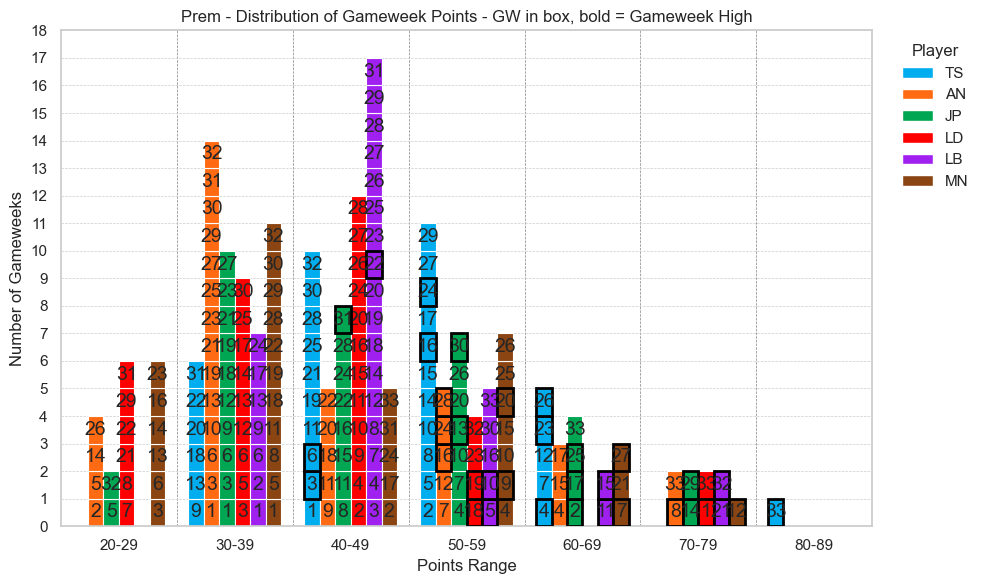

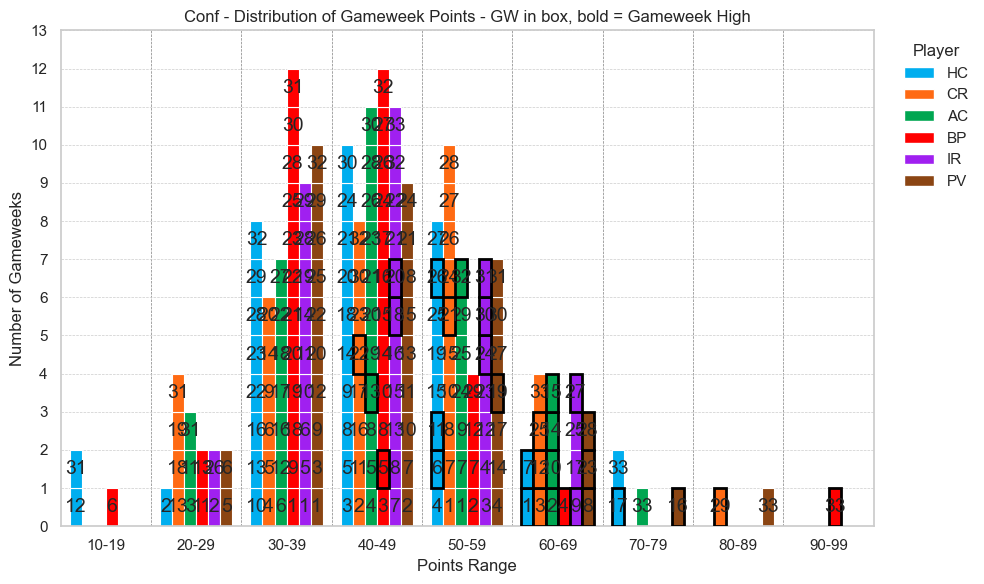

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Patch

def plot_gameweek_blocks(weekly_summary, choose_league, colour_palette, save_path=None, title_suffix=""):
    """
    Plot stacked gameweek blocks per player by 10-point score bins.
    Each block = 1 gameweek. Stacks represent counts within bins per player.
    Players are shown side-by-side for each bin.
    Blocks with a thick black outline mark the gameweek high score.
    """

    # --- 1) Filter for selected league ---
    df = weekly_summary[weekly_summary["league_code"] == choose_league].copy()
    if df.empty:
        print(f"No data found for league '{choose_league}'. Skipping plot.")
        return
    
    game_week_agg = ( 
        df.groupby(["league_code", "gameweek", "short_name"])["points_scored"] 
        .sum() 
        .reset_index() 
    )

    # --- ⭐ 2) Identify gameweek highs within this league ---
    gw_highs = (
        game_week_agg.groupby("gameweek")["points_scored"]
        .transform(lambda x: x == x.max())
    )
    game_week_agg["is_gw_high"] = gw_highs

    # --- 3) Define 10-point bins dynamically ---
    min_points = game_week_agg["points_scored"].min()
    max_points = game_week_agg["points_scored"].max()

    lower_edge = int(np.floor(min_points / 10.0) * 10)
    upper_edge = int(np.ceil((max_points+1) / 10.0) * 10) + 10

    bins = range(lower_edge, upper_edge, 10)
    labels = [f"{b}-{b+9}" for b in bins[:-1]]

    game_week_agg["score_bin"] = pd.cut(game_week_agg["points_scored"], bins=bins, labels=labels, right=False)
    game_week_agg = game_week_agg.dropna(subset=["score_bin"])

    # --- 4) Player order based on colour_palette ---
    players_present = [p for p in colour_palette.keys() if p in game_week_agg["short_name"].unique()]
    if not players_present:
        print(f"No matching players found for '{choose_league}'.")
        return

    # --- 5) Compute stack index per (player, bin) ---
    game_week_agg = game_week_agg.sort_values(["short_name", "score_bin", "gameweek"])
    game_week_agg["stack_idx"] = game_week_agg.groupby(["short_name", "score_bin"]).cumcount()

    # --- 6) Layout setup ---
    bin_to_x = {lab: i for i, lab in enumerate(labels)}
    x_base = np.arange(len(labels))

    n_players = max(1, len(players_present))
    total_bar_width = 0.8
    bar_width = total_bar_width / n_players
    offsets = {
        p: (-total_bar_width / 2) + (i + 0.5) * bar_width
        for i, p in enumerate(players_present)
    }

    max_heights = (
        game_week_agg.groupby(["short_name", "score_bin"])["stack_idx"]
        .max()
        .fillna(0)
        .astype(int)
        + 1
    )
    max_height_overall = int(max_heights.max()) if not max_heights.empty else 1

    # # --- 7) Plot ---
    # fig, ax = plt.subplots(figsize=(14, 7))
    # legend_handles = []

    # for p in players_present:
    #     dfp = game_week_agg[game_week_agg["short_name"] == p]

    #     for _, row in dfp.iterrows():
    #         xb = bin_to_x[row["score_bin"]]
    #         x = xb + offsets[p]
    #         bottom = row["stack_idx"]

    #         # ⭐ Thicker black edge if it’s the gameweek high
    #         edge_color = "black" if row["is_gw_high"] else "white"
    #         line_width = 2.0 if row["is_gw_high"] else 0.8

    #         ax.bar(
    #             x, 1, width=bar_width, bottom=bottom,
    #             color=colour_palette[p], edgecolor=edge_color, linewidth=line_width
    #         )
    #         ax.text(
    #             x, bottom + 0.5, str(int(row["gameweek"])),
    #             ha="center", va="center", fontsize=16
    #         )

    #     legend_handles.append(Patch(facecolor=colour_palette[p], edgecolor="white", label=p))

    # --- 7) Plot ---
    fig, ax = plt.subplots(figsize=(10, 6))
    legend_handles = []

    # --- Pass 1: normal blocks (non-highs) ---
    for p in players_present:
        dfp = game_week_agg[game_week_agg["short_name"] == p]

        # Normal blocks only
        for _, row in dfp[~dfp["is_gw_high"]].iterrows():
            xb = bin_to_x[row["score_bin"]]
            x = xb + offsets[p]
            bottom = row["stack_idx"]

            ax.bar(
                x, 1, width=bar_width, bottom=bottom,
                color=colour_palette[p], edgecolor="white", linewidth=0.8,
                zorder=2
            )
            ax.text(
                x, bottom + 0.5, str(int(row["gameweek"])),
                ha="center", va="center", fontsize=14, zorder=3
            )

        legend_handles.append(Patch(facecolor=colour_palette[p], edgecolor="white", label=p))

    # --- Pass 2: overlay highs last so their edges sit on top ---
    for p in players_present:
        dfp = game_week_agg[game_week_agg["short_name"] == p]
        for _, row in dfp[dfp["is_gw_high"]].iterrows():
            xb = bin_to_x[row["score_bin"]]
            x = xb + offsets[p]
            bottom = row["stack_idx"]

            ax.bar(
                x, 1, width=bar_width, bottom=bottom,
                color=colour_palette[p], edgecolor="black", linewidth=2.0,
                zorder=4  # ensure drawn above everything else
            )
            ax.text(
                x, bottom + 0.5, str(int(row["gameweek"])),
                ha="center", va="center", fontsize=14, zorder=5
            )


    # --- 8) Axes, ticks, and grids ---
    ax.set_xticks(x_base)
    ax.set_xticklabels(labels, rotation=0)
    ax.set_xlim(-0.5, len(labels) - 0.5)

    ax.set_ylim(0, max(max_height_overall + 1, 3))
    ax.yaxis.set_major_locator(MultipleLocator(1))

    ax.grid(False)
    ax.grid(axis="y", which="major", linestyle="--", linewidth=0.5)

    # Vertical dividers BETWEEN bins
    for x in np.arange(-0.5, len(labels) - 0.5):
        ax.axvline(x + 1, color="grey", linestyle="--", linewidth=0.5, zorder=0)

    # --- 9) Labels, title, legend ---
    title = f"{choose_league} - Distribution of Gameweek Points - GW in box, bold = Gameweek High"
    if title_suffix:
        title += f" – {title_suffix}"
    ax.set_title(title)

    ax.set_xlabel("Points Range")
    ax.set_ylabel("Number of Gameweeks")

    if legend_handles:
        ax.legend(handles=legend_handles, title="Player",
                  bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

    plt.tight_layout()

    # --- 10) Save if requested ---
    if save_path:
        filename = f"point_distribution_{choose_league}_GW{current_week}.png"
        if os.path.exists(filename):
            os.remove(filename)
        plt.savefig(filename, bbox_inches="tight")
    else:
        plt.show()

    # plt.show()

for league in ['Prem', 'Conf']:
    plot_gameweek_blocks(
        weekly_summary,
        choose_league=league,
        colour_palette=colour_palette,
        save_path=True
    )


In [ ]:
agg_weekly = weekly_summary.groupby(['league_code', 'short_name', 'gameweek'])['points_scored'].sum().reset_index()
agg_weekly['cumulative_mean_points_scored'] = agg_weekly.groupby(['short_name'])['points_scored'].expanding().mean().reset_index(level=0, drop=True)


# agg_weekly = agg_weekly[agg_weekly['league_code'] == choose_league]


# # Plot the rolling average weekly points score by week over time
import matplotlib.pyplot as plt
import seaborn as sns

def plot_weekly_avg(agg_weekly, current_week, choose_league, save_path = None):
    agg_weekly_league = agg_weekly[agg_weekly['league_code'] == choose_league]
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=agg_weekly_league, x='gameweek', y='cumulative_mean_points_scored', hue='short_name', palette=colour_palette, marker='o', markersize=5)
    # Label the lines with the short_name
    current_week = agg_weekly_league['gameweek'].max()
    for name, group in agg_weekly_league.groupby('short_name'):
        plt.text(current_week + 0.1, group['cumulative_mean_points_scored'].iloc[-1], name, fontsize=9, verticalalignment='center')
    plt.xticks(range(1, current_week + 1))
    plt.legend(title='Name', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    plt.title(choose_league + ' - Rolling Average Weekly Points Score by Week')
    plt.xlabel('Gameweek')
    plt.ylabel('Rolling Average Points Scored')
    plt.ylim(35, 55)
    plt.legend(title='Name')
    plt.grid(True)
    plt.tight_layout()

    # Save and/or show
    if save_path:
        filename = f"cumulative_points_{choose_league}_GW{current_week}.png"
        if os.path.exists(filename):
            os.remove(filename)
        plt.savefig(filename, bbox_inches="tight")
    else:
        plt.show()
    
    plt.close()


    plt.show()

for league in ['Prem','Conf']:
    plot_weekly_avg(agg_weekly, current_week, league, save_path = True)

In [ ]:
league_comparison = player_points_weekly.pivot_table(index = ['gameweek', 'web_name', 'team_name', 'rank_in_week', 'total_points'], columns = 'league_code', values = 'short_name', fill_value = 0, aggfunc = 'first').reset_index().sort_values(by = ['gameweek', 'rank_in_week'], ascending = [True, True])
league_comparison = league_comparison[(league_comparison['Conf'] == 'Not Drafted') | (league_comparison['Prem'] == 'Not Drafted')]
league_comparison = league_comparison[league_comparison['rank_in_week'] <= 18]
league_comparison.rename(columns = {'web_name': 'player_name'}, inplace = True)
league_comparison['player_name'] = league_comparison['player_name'] + " (" + league_comparison['team_name'] + ")"
league_comparison = league_comparison[["gameweek", "rank_in_week", "player_name", "total_points", "Prem", "Conf"]]
league_comparison.columns = ['_'.join(map(str, col)).strip() if isinstance(col, tuple) else col
              for col in league_comparison.columns]
league_comparison.columns.name = None
league_comparison

,gameweek,rank_in_week,player_name,total_points,Prem,Conf
59,1,1,Ballard (SUN),17,Not Drafted,Not Drafted
111,1,3,Calafiori (ARS),13,Not Drafted,Not Drafted
536,1,3,Richarlison (TOT),13,Not Drafted,Not Drafted
371,1,7,Lewis (MCI),11,Not Drafted,Not Drafted
480,1,9,O'Riley (BHA),10,Not Drafted,Not Drafted
...,...,...,...,...,...,...
25015,33,12,Georginio (BHA),12,Not Drafted,Not Drafted
25063,33,15,Heaven (MUN),11,Not Drafted,Not Drafted
25173,33,15,Lacroix (CRY),11,LB (Benched),Not Drafted
25434,33,15,Shaw (MUN),11,Not Drafted,HC


In [ ]:
league_h2h = weekly_summary.groupby(['league_code', 'gameweek'])['points_scored'].sum().reset_index()
league_h2h_print = league_h2h.pivot(index='gameweek', columns='league_code', values='points_scored').reset_index()
league_h2h_print.columns.name = None  # remove the columns name
league_h2h_print['Prem - Win'] = np.where(league_h2h_print['Prem'] > league_h2h_print['Conf'], 1, 0)
league_h2h_print['Conf - Win'] = np.where(league_h2h_print['Conf'] > league_h2h_print['Prem'], 1, 0)
# add a totals row to the bottom
totals_row = pd.DataFrame(league_h2h_print[['Prem', 'Conf', 'Prem - Win', 'Conf - Win']].sum()).T
totals_row['gameweek'] = 'Running Total'
league_h2h_print = pd.concat([league_h2h_print, totals_row], ignore_index=True)
league_h2h_print = league_h2h_print.rename(columns={'gameweek': 'GW', 'Prem': 'Prem Points', 'Conf': 'Conf Points'})
league_h2h_print = league_h2h_print[['GW', 'Prem Points', 'Conf Points', 'Prem - Win', 'Conf - Win']]
league_h2h_print

,GW,Prem Points,Conf Points,Prem - Win,Conf - Win
0,1,251,284,0,1
1,2,271,254,1,0
2,3,226,263,0,1
3,4,321,300,1,0
4,5,230,231,0,1
5,6,197,204,0,1
6,7,311,313,0,1
7,8,287,290,0,1
8,9,254,266,0,1
9,10,283,275,1,0


In [ ]:
def get_transfer_history(league_code, all_players):
    table = get_league_table(league_code)
    url = f"https://draft.premierleague.com/api/draft/league/{league_code}/transactions"
    r = requests.get(url)
    json_raw = r.json()
    
    transfers = pd.json_normalize(json_raw["transactions"])
    
    transfers = transfers.merge(all_players[["id", "web_name", "position"]], left_on = "element_in", right_on = "id", how = "inner")
    transfers.rename(columns = {"web_name": "player_in"}, inplace = True)
    transfers = transfers.merge(all_players[["id", "web_name"]], left_on = "element_out", right_on = "id", how = "inner")
    transfers.rename(columns = {"web_name": "player_out"}, inplace = True)
    transfers = transfers.merge(table[["entry_id", "short_name"]], left_on = "entry", right_on = "entry_id", how = "inner")
    transfers.rename(columns = {"short_name": "person"}, inplace = True)
    
    transfers = transfers[["added", "event", "index", "kind", "priority", "result", "position", "element_in", "player_in", "element_out", "player_out", "person"]]
    transfers['league_code'] = league_code
    
    return transfers

transfers = pd.concat([get_transfer_history(codes["Prem"], all_players), get_transfer_history(codes["Conf"], all_players)])
transfers['attempted_transfers'] = 1
transfers['successful_transfers'] = np.where(transfers['result'] == 'a', 1, 0)
transfers['attempted_transfers'] = pd.to_numeric(transfers['attempted_transfers'])
transfers['successful_transfers'] = pd.to_numeric(transfers['successful_transfers'])
transfers['league_code'] = transfers['league_code'].replace(code_to_name)
transfers = transfers.merge(player_points_weekly, left_on = ['league_code', 'event', 'element_in'], right_on = ['league_code', 'gameweek', 'id'])
transfers = transfers.rename(columns = {'total_points' : 'player_in_points_scored_in_week', 'total_points_scored_after_gameweek' :'player_in_points_scored_after'})
transfers = transfers.merge(player_points_weekly, left_on = ['league_code', 'event', 'element_out'], right_on = ['league_code', 'gameweek', 'id'])
transfers = transfers.rename(columns = {'total_points' : 'player_out_points_scored_in_week', 'total_points_scored_after_gameweek' :'player_out_points_scored_after'})
transfers['kind'] = transfers['kind'].map({'w': 'waiver', 'f': 'free agent'})
transfers['result'] = transfers['result'].map({'a': 'successful', 'do': 'unsuccessful - player out already gone', 'di': 'unsuccessful - player in already been picked up'})
transfers['added'] = pd.to_datetime(transfers['added'])
transfers.rename(columns={'added': 'date_added', 'event': 'gameweek', 'person': 'short_name'}, inplace=True)
# transfers = transfers[transfers['gameweek'] == current_week]
transfers = transfers[['league_code', 'date_added', 'gameweek', 'short_name', 'kind', 'result', 'index', 'priority', 'position', 'element_in', 'player_in', 'element_out', 'player_out', 'player_in_points_scored_in_week', 'player_out_points_scored_in_week']]
transfers['net_points_of_transfer_in_week'] = transfers['player_in_points_scored_in_week'] - transfers['player_out_points_scored_in_week']
transfers['player_in'] = transfers['player_in'] + ' (' + transfers['player_in_points_scored_in_week'].astype(str) + ')'
transfers['player_out'] = transfers['player_out'] + ' (' + transfers['player_out_points_scored_in_week'].astype(str) + ')'
transfers['abs_net_trade'] = np.abs(transfers['net_points_of_transfer_in_week'])
# transfers = transfers.sort_values(by=['league_code', 'index', 'date_added'], ascending=[False, True, True])  # Sort by league_code, index, and date_added
transfers = transfers.sort_values(by = ['league_code', 'abs_net_trade'], ascending = [False, False])
transfers

,league_code,date_added,gameweek,short_name,kind,result,index,priority,position,element_in,player_in,element_out,player_out,player_in_points_scored_in_week,player_out_points_scored_in_week,net_points_of_transfer_in_week,abs_net_trade
13,Prem,2025-08-21 07:08:55.949857+00:00,2,TS,waiver,successful,9.0,2.0,DEF,74,Truffert (6),8,J.Timber (24),6,24,-18,18
132,Prem,2025-10-12 17:16:51.407588+00:00,8,AN,waiver,successful,1.0,1.0,DEF,225,James (18),473,Hall (0),18,0,18,18
394,Prem,2026-02-09 09:27:25.512927+00:00,26,MN,waiver,successful,10.0,3.0,DEF,371,Kerkez (0),720,Hincapie (15),0,15,-15,15
463,Prem,2026-03-17 20:50:21.478749+00:00,31,LB,waiver,successful,5.0,2.0,DEF,508,N.Williams (15),257,Lacroix (0),15,0,15,15
535,Prem,2026-04-16 21:11:44.261367+00:00,33,AN,waiver,unsuccessful - player in already been picked up,32.0,11.0,DEF,406,Khusanov (15),7,Calafiori (0),15,0,15,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876,Conf,2026-03-13 09:47:46.364956+00:00,30,PV,waiver,unsuccessful - player out already gone,7.0,3.0,MID,84,Tavernier (3),413,Marmoush (3),3,3,0,0
883,Conf,2026-03-19 09:14:09.948973+00:00,31,CR,waiver,successful,7.0,3.0,DEF,370,Frimpong (0),402,Aït-Nouri (0),0,0,0,0
885,Conf,2026-03-19 10:21:59.722715+00:00,31,HC,waiver,successful,1.0,1.0,MID,593,P.M.Sarr (2),708,M.Fernandes (2),2,2,0,0
890,Conf,2026-03-20 13:17:15.301358+00:00,31,IR,free agent,successful,NaN,NaN,DEF,322,Tete (0),257,Lacroix (0),0,0,0,0


In [ ]:
player_points_weekly

,id,total_points,gameweek,rank_in_week,element_x,short_name,place,isBenched,league_code,element_y,...,draft_index,team,gameweek_matches,opposition,home_away,team_score,opposition_score,team_difficulty,opposition_difficulty,kickoff_time_first
0,531,17,1,1,NaN,Not Drafted,NaN,0,Conf,531,...,NaN,SUN,1.0,WHU,H,3.0,0.0,2.0,3.0,2025-08-16 14:00:00+00:00
1,82,15,1,2,82,HC,8,0,Conf,82,...,25.0,MCI,1.0,WOL,A,4.0,0.0,2.0,4.0,2025-08-16 16:30:00+00:00
2,7,13,1,3,NaN,Not Drafted,NaN,0,Conf,7,...,NaN,ARS,1.0,MUN,A,1.0,0.0,4.0,4.0,2025-08-17 15:30:00+00:00
3,430,13,1,3,430,HC,9,0,Conf,430,...,1.0,MCI,1.0,WOL,A,4.0,0.0,2.0,4.0,2025-08-16 16:30:00+00:00
4,525,13,1,3,525,CR,11,0,Conf,525,...,22.0,NFO,1.0,BRE,H,3.0,1.0,3.0,3.0,2025-08-17 13:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51127,826,0,33,301,NaN,Not Drafted,NaN,0,Prem,826,...,NaN,BRE,1.0,FUL,H,0.0,0.0,3.0,3.0,2026-04-18 11:30:00+00:00
51128,827,0,33,301,NaN,Not Drafted,NaN,0,Prem,827,...,NaN,MUN,1.0,CHE,A,1.0,0.0,3.0,3.0,2026-04-18 19:00:00+00:00
51129,828,0,33,301,NaN,Not Drafted,NaN,0,Prem,828,...,NaN,WOL,1.0,LEE,A,0.0,3.0,3.0,1.0,2026-04-18 14:00:00+00:00
51130,829,0,33,301,NaN,Not Drafted,NaN,0,Prem,829,...,NaN,CHE,2.0,MUN-BHA,HA,0.0,2.0,3.5,3.0,2026-04-18 19:00:00+00:00


In [ ]:
def get_trade_history(league_code, player_points_weekly):
    table = get_league_table(league_code)
    url = f"https://draft.premierleague.com/api/draft/league/{league_code}/trades"
    r = requests.get(url)
    json_raw = r.json()
    
    # ✅ Handle empty trade case
    if not json_raw.get("trades"):
        # print(f"No trades found for league {league_code}")
        return pd.DataFrame(columns=['league_code', 'GW traded', 'player_in', 'player_in_total_points', 'player_out', 'player_out_total_points', 'net_points_from_trade'])
    trades = pd.json_normalize(json_raw["trades"])[['event', 'offered_entry', 'received_entry', 'tradeitem_set']]

    # Expand each tradeitem_set (which is a list of dicts)
    trades_expanded = trades.explode('tradeitem_set').reset_index(drop=True)
    
    # Normalize the nested dicts inside tradeitem_set
    trade_items = pd.json_normalize(trades_expanded['tradeitem_set'])
    
    # Merge back with the event column
    trades_final = pd.concat([trades_expanded[['event', 'offered_entry', 'received_entry']], trade_items], axis=1)
    trades_final = trades_final.merge(table[["entry_id", "short_name"]], left_on = "offered_entry", right_on = "entry_id", how = "inner")
    trades_final.rename(columns = {"short_name": "offered_by"}, inplace = True)
    trades_final = trades_final.merge(table[["entry_id", "short_name"]], left_on = "received_entry", right_on = "entry_id", how = "inner")
    trades_final.rename(columns = {"short_name": "received_by"}, inplace = True)
    
    # If you only want element_in and element_out:
    trades_final = trades_final[['event', 'element_in', 'element_out', 'offered_by', 'received_by']]

    trades_final['league_code'] = league_code
    trades_final['league_code'] = trades_final['league_code'].replace(code_to_name)

    trades_final = trades_final.merge(player_points_weekly[['id', 'web_name', 'gameweek', 'total_points', 'league_code']], left_on = ['element_in', 'league_code'], right_on = ['id', 'league_code'], how = 'left')
    trades_final = trades_final[trades_final['event'] <= trades_final['gameweek']]
    trades_final.rename(columns = {'web_name': 'player_in', 'total_points': 'player_in_total_points'}, inplace = True)
    trades_final = trades_final.merge(player_points_weekly[['id', 'web_name', 'gameweek', 'total_points', 'league_code']], left_on = ['element_out', 'league_code', 'gameweek'], right_on = ['id', 'league_code', 'gameweek'], how = 'left')
    trades_final.rename(columns = {'web_name': 'player_out', 'total_points': 'player_out_total_points', 'event': 'GW traded'}, inplace = True)
    
    trades_final = trades_final[['league_code', 'GW traded', 'offered_by', 'element_in', 'player_in', 'gameweek', 'player_in_total_points', 'received_by', 'element_out', 'player_out', 'player_out_total_points']]

    #player_in_total_points_cumulative
    trades_final = trades_final.sort_values(by = ['league_code', 'GW traded', 'offered_by', 'received_by', 'player_in', 'player_out', 'gameweek'], ascending = [False, True, True, True, True, True, True])
    
    trades_final['player_in_total_points'] = pd.to_numeric(trades_final['player_in_total_points'])
    trades_final['player_out_total_points'] = pd.to_numeric(trades_final['player_out_total_points'])
    # trades_final['player_in_total_points_cumulative'] = trades_final.groupby(['league_code', 'player_in', 'offered_by'])['player_in_total_points'].cumsum()
    # trades_final['player_out_total_points_cumulative'] = trades_final.groupby(['league_code', 'player_out', 'received_by'])['player_out_total_points'].cumsum()

    trade_summary = trades_final.groupby(['league_code', 'GW traded', 'offered_by', 'received_by', 'element_in', 'player_in', 'element_out', 'player_out']).agg({
        'player_in_total_points': 'sum',
        'player_out_total_points': 'sum'
    }).reset_index()

    trade_summary['net_points_from_trade'] = trade_summary['player_in_total_points'] - trade_summary['player_out_total_points']
    trade_summary['element_in'] = trade_summary['element_in'].astype(int)
    trade_summary['element_out'] = trade_summary['element_out'].astype(int)
    
    return trade_summary

trade_history = pd.concat([get_trade_history(codes['Prem'], player_points_weekly), get_trade_history(codes['Conf'], player_points_weekly)])
trade_history['Points Since Trade'] = trade_history['offered_by'] + ' offered to have ' + trade_history['player_in'] + ' (' + trade_history['player_in_total_points'].astype(str) + ') for ' + trade_history['player_out'] + ' (' + trade_history['player_out_total_points'].astype(str) + ') to ' + trade_history['received_by']
trade_history

,league_code,GW traded,offered_by,received_by,element_in,player_in,element_out,player_out,player_in_total_points,player_out_total_points,net_points_from_trade,Points Since Trade
0,Prem,11,TS,LD,237.0,Enzo,384.0,Gakpo,88,72,16,TS offered to have Enzo (88) for Gakpo (72) to LD
1,Prem,12,AN,TS,450.0,Cunha,119.0,Mbeumo,99,66,33,AN offered to have Cunha (99) for Mbeumo (66) ...
2,Prem,22,JP,MN,661.0,Gyökeres,715.0,Woltemade,53,17,36,JP offered to have Gyökeres (53) for Woltemade...
3,Prem,28,LB,MN,235.0,Palmer,16.0,Saka,20,14,6,LB offered to have Palmer (20) for Saka (14) t...


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_weekly_heatmap(weekly_summary, transfers, trade_history, current_week, choose_league, save_path=None):
    # ---- Filter data ----
    data_to_plot = weekly_summary[
        (weekly_summary['gameweek'] == current_week) & 
        (weekly_summary['league_code'] == choose_league)
    ].copy()
    
    # ---- Subs info ----
    data_to_plot['isSub'] = np.where(
        ((data_to_plot['originally_starting'] == 1) & (data_to_plot['place'] > 11)), '(SF) ',
        np.where(((data_to_plot['originally_starting'] == 0) & (data_to_plot['place'] <= 11)), '(SN) ', '')
    )
    
    # ---- Merge transfers ----
    data_to_plot = data_to_plot.merge(
        transfers[transfers['gameweek'] == current_week][['league_code', 'gameweek', 'short_name', 'element_in', 'player_in', 'kind']], 
        left_on=['league_code', 'gameweek', 'short_name', 'element'], 
        right_on=['league_code', 'gameweek', 'short_name', 'element_in'], 
        how='left'
    )
    
    data_to_plot = data_to_plot.merge(
        transfers[transfers['gameweek'] == current_week][transfers['result'] != 'successful'][['league_code', 'gameweek', 'short_name', 'element_out', 'player_out']].drop_duplicates(),
        left_on=['league_code', 'gameweek', 'short_name', 'element'],
        right_on=['league_code', 'gameweek', 'short_name', 'element_out'],
        how='left'
    )

    # ---- Transfers flag ----
    data_to_plot['isTransfer'] = np.where(((~data_to_plot['element_in'].isna()) & (data_to_plot['kind'] == 'waiver')), '(W) ',
                                          np.where(((~data_to_plot['element_in'].isna()) & (data_to_plot['kind'] == 'free agent')), '(F) ',
                                                   np.where((~data_to_plot['element_out'].isna()), '(AW) ', '')
                                                   )
                                          )
    
    transfer_week = transfers.groupby(['league_code', 'short_name', 'element_in'])['gameweek'].max().reset_index()
    transfer_week = transfer_week.rename(columns={'gameweek': 'transfer_week'})
    data_to_plot = data_to_plot.merge(transfer_week, left_on=['league_code', 'short_name', 'element'], right_on=['league_code', 'short_name', 'element_in'], how='left') 
    data_to_plot = data_to_plot.merge(trade_history[['league_code', 'element_in', 'GW traded', 'offered_by']], left_on=['league_code', 'short_name', 'element'], right_on=['league_code', 'offered_by', 'element_in'], how='left')
    data_to_plot = data_to_plot.rename(columns={'GW traded': 'trade_week_in'})
    data_to_plot = data_to_plot.merge(trade_history[['league_code', 'element_out', 'GW traded', 'received_by']], left_on=['league_code', 'short_name', 'element'], right_on=['league_code', 'received_by', 'element_out'], how='left')
    data_to_plot = data_to_plot.rename(columns={'GW traded': 'trade_week_out'})
    data_to_plot['trade_week'] = np.where(~data_to_plot['trade_week_in'].isna(), data_to_plot['trade_week_in'],
                                          np.where(~data_to_plot['trade_week_out'].isna(), data_to_plot['trade_week_out'], np.nan))

    # ---- Player summary ----
    data_to_plot['player_summary'] = (
        data_to_plot['isTransfer'] + data_to_plot['isSub'] + 
        data_to_plot['web_name'] +
        " - " + data_to_plot['total_points'].astype(str)  + "\n" +  # position on top line
        data_to_plot['position'] + " - " + data_to_plot['team_name'] + "\n" +
        np.where(data_to_plot['round'] != 0, "D" + data_to_plot['round'].astype(str),
                 np.where(~data_to_plot['trade_week'].isna(), "Td" + data_to_plot['trade_week'].fillna(0).astype(int).astype(str),
                 "Tn" + data_to_plot['transfer_week'].fillna(0).astype(int).astype(str))) + " - " +
        data_to_plot['player_total_points'].astype(str) + " S (" + data_to_plot['points_scored_cumulative'].astype(str) + " R)"
        
    )

    # ---- Order columns by total points ----
    col_order = (
        league_table[league_table['league_code'] == choose_league].groupby("short_name")["total"]
        .sum()
        .sort_values(ascending=False)
        .index
    )
    
    heatmap_data = data_to_plot.pivot_table(
        index="place", columns="short_name", values="total_points", fill_value=0
    ).reindex(columns=col_order)
    
    annot_data = data_to_plot.pivot_table(
        index="place", columns="short_name", values="player_summary",
        fill_value="", aggfunc="first"
    ).reindex(columns=col_order)

    heatmap_for_plot = heatmap_data.copy()

    # ---- Plot ----
    plt.figure(figsize=(13, 7.5))  # compact height for 6-team league

    ax = sns.heatmap(
        heatmap_for_plot,
        annot=annot_data,
        fmt="",
        cmap="YlGn",
        cbar_kws={'label': 'Points Scored'},
        annot_kws={"size": 9},  # smaller cell text
        xticklabels=True,
        yticklabels=True
    )

    # Remove X and Y axis labels (they add no value here)
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Add horizontal line separating starters from bench
    ax.hlines(y=11, xmin=0, xmax=heatmap_for_plot.shape[1], colors='black', linewidth=2)

    # Optional: tighten spacing for laptop viewing
    plt.title(f"{choose_league} - Gameweek {current_week}", pad=10, fontsize=14)
    # plt.xticks(rotation=45, ha="right")
    # plt.xticks([], [])  # hide tick labels
    # ax.set_xlabel("")

    plt.yticks(rotation=0)

    # ---- Add manager (short_name) totals under the heatmap, aligned per column ----
    # Calculate GW total points per manager (sum for each team)
    gw_totals = (
        data_to_plot.groupby("short_name")["points_scored"].sum()
        .reindex(heatmap_for_plot.columns)
    )

    # Hide default x tick labels
    ax.set_xticklabels([])
    ax.set_xlabel("")

    # Make room at the bottom for text
    plt.subplots_adjust(bottom=0.18)

    # Get x tick positions (center of each column)
    xticks = ax.get_xticks()

    # Draw each manager name + total beneath its column
    for x, name in zip(xticks, gw_totals.index):
        total = gw_totals[name]
        label = f"{name} ({int(total)})"
        ax.text(
            x, 15.2,             # just below the lowest grid row (data coords)
            label,
            ha="center", va="top",
            fontsize=14, color='black',
            transform=ax.transData    # data-space positioning (works well here)
            # clip_on=False              # allow text outside plot bounds
        )

    plt.tight_layout(pad=0.5)

    # Remove large legend padding if you want it flush
    ax.figure.axes[-1].set_ylabel('')  # remove colorbar label if you prefer
    ax.figure.axes[-1].yaxis.labelpad = 5

    # Explanatory footer text (still fits comfortably)
    plt.text(
        0.5, -0.12,
        'W = Waiver in week, F = Free Agent in week, AW = Attempted Waiver in week, SN = Subbed on, SF = Subbed off\n'
        'D# = Draft Round Pick #, Tn# = Transferred in GW#, Td# = Traded in GW#, S = Season Total Points, R = Points Realised by Drafter',
        ha='center', va='center', transform=ax.transAxes,
        fontsize=10, color='black'
    )

    # Save or show
    if save_path:
        filename = f"weekly_points_heatmap_{choose_league}_GW{current_week}.png"
        if os.path.exists(filename):
            os.remove(filename)
        plt.savefig(filename, bbox_inches="tight")
    else:
        plt.show()

    plt.close()

for league in ['Prem', 'Conf']:
    plot_weekly_heatmap(
        weekly_summary=weekly_summary,
        transfers=transfers,
        trade_history=trade_history,
        current_week=current_week,
        choose_league=league,
        save_path=True   # or None if you only want to show
    )


C:\Users\MikeNelson\AppData\Local\Temp\ipykernel_4120\304718102.py:28: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  transfers[transfers['gameweek'] == current_week][transfers['result'] != 'successful'][['league_code', 'gameweek', 'short_name', 'element_out', 'player_out']].drop_duplicates(),
C:\Users\MikeNelson\AppData\Local\Temp\ipykernel_4120\304718102.py:58: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  np.where(~data_to_plot['trade_week'].isna(), "Td" + data_to_plot['trade_week'].fillna(0).astype(int).astype(str),
C:\Users\MikeNelson\AppData\Local\Temp\ipykernel_4120\304718102.py:59: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(c

In [ ]:
# Impact of subs
# Using for each short_name calculate sum of optimal_points subtract from sum of points_scored
total_points_lost_through_subs = weekly_summary.groupby(['short_name']).apply(
    lambda x: (x['optimal_points'].sum() - x['points_scored'].sum())
).reset_index(name='total_points_lost_through_subs')

# max_possible_points_lost_through_subs = weekly_summary.groupby(['short_name']).apply(
#     lambda x: (x['optimal_points'].sum() - x['suboptimal_points'].sum())
# ).reset_index(name='total_max_possible_points_lost_through_subs')

weekly_impact_of_subs = weekly_summary[weekly_summary['gameweek'] == current_week].groupby(['league_code', 'short_name']).apply(
    lambda x: (x['optimal_points'].sum() - x['points_scored'].sum())
).reset_index(name='net_points_lost_through_subs')

# weekly_possible_impact_of_subs = weekly_summary[weekly_summary['gameweek'] == current_week].groupby(['short_name']).apply(
#     lambda x: (x['optimal_points'].sum() - x['suboptimal_points'].sum())
# ).reset_index(name='max_possible_points_lost_through_subs')

# impact_of_subs = weekly_impact_of_subs.merge(weekly_possible_impact_of_subs, on='short_name', how='left')
# impact_of_subs = impact_of_subs.merge(total_points_lost_through_subs, on='short_name', how='left')
impact_of_subs = weekly_impact_of_subs.merge(total_points_lost_through_subs, on='short_name', how='left')
# impact_of_subs = impact_of_subs.merge(max_possible_points_lost_through_subs, on='short_name', how='left')
impact_of_subs = impact_of_subs.sort_values(by=['league_code', 'net_points_lost_through_subs'], ascending=[False, False])
# impact_of_subs

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_subs_barcharts(
    weekly_summary: pd.DataFrame,
    impact_of_subs: pd.DataFrame,
    current_week: int,
    choose_league: str,
    save_path: bool = True
):
    """
    Plot a horizontal bar chart per league with:
      - Grey bar: total_points_lost_through_subs
      - Light blue bar: net_points_lost_through_subs (for current_week)
    Bars are labeled with their values. Figure is saved as PNG or shown.

    Parameters
    ----------
    weekly_summary : pd.DataFrame
        Original weekly data (not used directly here but kept for signature parity).
    impact_of_subs : pd.DataFrame
        Must contain columns: ['league_code','short_name','net_points_lost_through_subs','total_points_lost_through_subs']
        As built in your snippet where net_points is only for current_week.
    current_week : int
        Current gameweek number (used in title/filename).
    choose_league : str
        League code to filter by (e.g., 'Prem', 'Conf').
    save_path : bool
        If True, saves a PNG with a derived filename; otherwise plt.show().
    """

    # Filter to league and sanity-check columns
    required_cols = {
        'league_code', 'short_name',
        'net_points_lost_through_subs',
        'total_points_lost_through_subs'
    }
    missing = required_cols.difference(impact_of_subs.columns)
    if missing:
        raise ValueError(f"impact_of_subs is missing columns: {missing}")

    df = (
        impact_of_subs
        .loc[impact_of_subs['league_code'] == choose_league, [
            'short_name',
            'net_points_lost_through_subs',
            'total_points_lost_through_subs'
        ]]
        .copy()
    )

    if df.empty:
        print(f"No rows found for league '{choose_league}'. Nothing to plot.")
        return

    # Sort by net weekly points lost desc (as in your snippet)
    df = df.sort_values('net_points_lost_through_subs', ascending=False)

    # Build plot
    short_names = df['short_name'].tolist()
    totals = df['total_points_lost_through_subs'].astype(float).to_numpy()
    weekly = df['net_points_lost_through_subs'].astype(float).to_numpy()

    # Safety: ensure weekly doesn't exceed totals; clip if needed (optional)
    weekly = np.minimum(weekly, totals)

    n = len(df)
    # Scale figure height nicely
    fig_height = max(3.0, min(0.5 * n + 1.0, 18.0))
    plt.figure(figsize=(10, fig_height))

    y_pos = np.arange(n)

    # Background/total bar (grey)
    plt.barh(y_pos, totals, color='#d0d0d0', edgecolor='none', label='Total lost (all weeks)')

    # Weekly/net bar (light blue) drawn on top
    plt.barh(y_pos, weekly, color='#8ecae6', edgecolor='none', label=f'Net lost (GW {current_week})')

    # Formatting
    plt.gca().invert_yaxis()  # Highest weekly loss at top
    plt.yticks(y_pos, short_names)
    plt.xlabel('Points')
    plt.title(f"Impact of Subs — {choose_league} (GW {current_week})")

    # X-limits with padding
    max_x = max(totals.max() if len(totals) else 0, weekly.max() if len(weekly) else 0)
    plt.xlim(0, max_x * 1.1 if max_x > 0 else 1)

    # Value labels on bars
    def _label_bars(values, y_positions, is_weekly=False):
        for v, y in zip(values, y_positions):
            if np.isnan(v):
                continue
            # Place labels slightly inside or at the end of the bar depending on length
            if v > 0:
                x = v
                if is_weekly:
                    x_text = x - max_x * 0.01
                    ha = 'right'
                else:
                    x_text = x - max_x * 0.01
                    ha = 'right'
                if v < max_x * 0.08:
                    x_text = v + max_x * 0.01
                    ha = 'left'
                plt.text(
                    x_text, y,
                    f"{int(round(v))}",   # <-- integer labels here
                    va='center', ha=ha, fontsize=14
                )


    _label_bars(totals, y_pos, is_weekly=False)
    _label_bars(weekly, y_pos, is_weekly=True)

    # Legend
    plt.legend(loc='lower right', frameon=False)

    plt.tight_layout()

    # Save or show
    if save_path:
        filename = f"weekly_sub_points_barchart_{choose_league}_GW{current_week}.png"
        if os.path.exists(filename):
            os.remove(filename)
        plt.savefig(filename, bbox_inches="tight", dpi=200)
        plt.close()
        print(f"Saved: {filename}")
    else:
        plt.show()


for league in ['Prem', 'Conf']:
    plot_subs_barcharts(
        weekly_summary=weekly_summary,
        impact_of_subs=impact_of_subs,
        current_week=current_week,
        choose_league=league,
        save_path=True  # or False to just show
    )



C:\Users\MikeNelson\AppData\Local\Temp\ipykernel_4120\2793317182.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  total_points_lost_through_subs = weekly_summary.groupby(['short_name']).apply(
C:\Users\MikeNelson\AppData\Local\Temp\ipykernel_4120\2793317182.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly_impact_of_subs = weekly_summary[weekly_summary['gameweek'] == current_week].groupby(['league_code',

Saved: weekly_sub_points_barchart_Prem_GW33.png
Saved: weekly_sub_points_barchart_Conf_GW33.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import MultipleLocator

transfers['transfer_category'] = transfers['kind'] + ' - ' + transfers['result']
transfer_summary = transfers.groupby(['league_code','short_name', 'transfer_category']).size().reset_index(name='count')

def plot_transfer_counts(transfer_summary, choose_league, save_path=None):
    df = transfer_summary[transfer_summary['league_code'] == choose_league]

    # Define categories
    success_cats = [
        'waiver - successful',
        'free agent - successful'
    ]
    fail_cats = [
        'waiver - unsuccessful - player out already gone',
        'waiver - unsuccessful - player in already been picked up'
    ]

    # Pivot tables
    pivot_success = (
        df[df['transfer_category'].isin(success_cats)]
        .pivot_table(index='short_name', columns='transfer_category', values='count', fill_value=0)
    )
    pivot_fail = (
        df[df['transfer_category'].isin(fail_cats)]
        .pivot_table(index='short_name', columns='transfer_category', values='count', fill_value=0)
    )

    # ✅ Sort by total successful transfers
    pivot_success['total_successful'] = pivot_success.sum(axis=1)
    pivot_success = pivot_success.sort_values(by='total_successful', ascending=False)
    pivot_fail = pivot_fail.reindex(pivot_success.index)  # keep same team order

    # Prepare for plotting
    teams = pivot_success.index
    x = np.arange(len(teams))
    width = 0.35

    # Colors
    transfer_palette = {
        'waiver - successful': '#4daf4a',
        'free agent - successful': '#377eb8',
        'waiver - unsuccessful - player out already gone': '#e41a1c',
        'waiver - unsuccessful - player in already been picked up': '#ff7f00'
    }

    plt.figure(figsize=(9, 3.5))

    # --- Successful (left bar per team) ---
    bottom = np.zeros(len(teams))
    for col in [c for c in success_cats if c in pivot_success.columns]:
        plt.bar(x - width/2, pivot_success[col], width,
                bottom=bottom, label=col, color=transfer_palette[col])
        bottom += pivot_success[col]

    # --- Unsuccessful (right bar per team) ---
    bottom = np.zeros(len(teams))
    for col in [c for c in fail_cats if c in pivot_fail.columns]:
        plt.bar(x + width/2, pivot_fail[col], width,
                bottom=bottom, label=col, color=transfer_palette[col])
        bottom += pivot_fail[col]

    # Labels, legend, grid
    plt.title(f'{choose_league} - Transfer Activity Over the Season')
    plt.xlabel('Team')
    plt.ylabel('Number of Transfers')
    plt.xticks(x, teams, rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title=None)

    ax = plt.gca()
    ax.yaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_minor_locator(MultipleLocator(1))
    plt.grid(which='major', axis='y', linestyle='-', linewidth=0.7)
    plt.grid(which='minor', axis='y', linestyle='--', linewidth=0.4, alpha=0.6)

    plt.tight_layout()

    # Save or show
    if save_path:
        filename = f"transfer_activity_{choose_league}_GW{current_week}.png"
        if os.path.exists(filename):
            os.remove(filename)
        plt.savefig(filename, bbox_inches="tight")
    else:
        plt.show()

    plt.close()

for league in ['Prem','Conf']:
    plot_transfer_counts(transfer_summary, league, save_path = True)

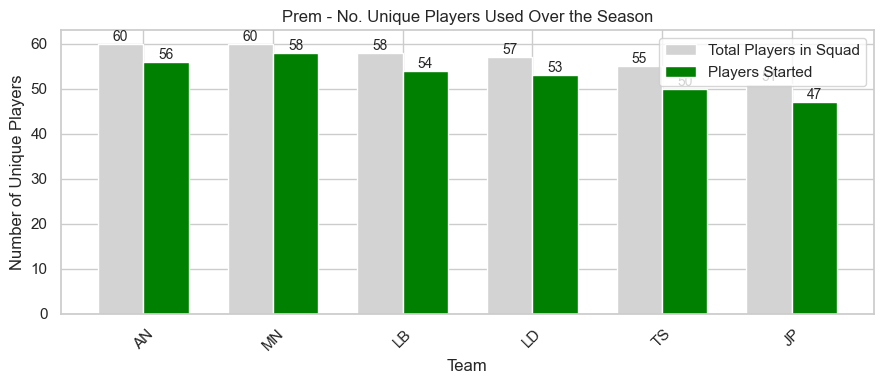

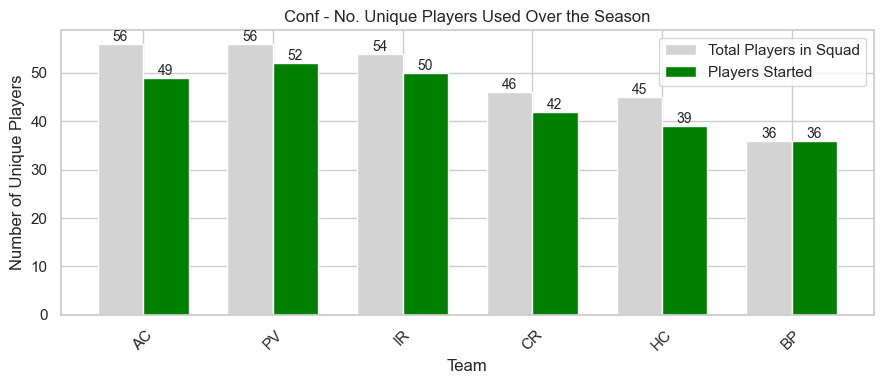

In [ ]:
import numpy as np

# Count unique players used

def plot_unique_players(weekly_summary, choose_league, save_path=None):
    df = weekly_summary[weekly_summary['league_code'] == choose_league]
    
    # Count unique players used (overall)
    unique_players = df.groupby('short_name')['element'].nunique().reset_index(name='unique_players_used')
    
    # Count unique players started (place <= 11)
    unique_players_started = df[df['place'].astype(int) <= 11].groupby('short_name')['element'].nunique().reset_index(name='unique_players_started')
    
    # Merge both metrics
    unique_players = unique_players.merge(unique_players_started, on='short_name')
    unique_players = unique_players.sort_values(by='unique_players_used', ascending=False)

    # Prepare for plotting
    melted = unique_players.melt(
        id_vars='short_name', 
        value_vars=['unique_players_used', 'unique_players_started'],
        var_name='Type', 
        value_name='Count'
    )

    plt.figure(figsize=(9, 4))
    
    # Create grouped bar chart
    x = np.arange(len(unique_players))
    width = 0.35
    
    ax = plt.gca()
    bars1 = ax.bar(x - width/2, unique_players['unique_players_used'], width, 
           label='Total Players in Squad', color='lightgray')
    bars2 = ax.bar(x + width/2, unique_players['unique_players_started'], width,
           label='Players Started', color='green')

    # Add value labels on top of bars
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10)
    
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10)

    plt.title(f'{choose_league} - No. Unique Players Used Over the Season')
    plt.xlabel('Team')
    plt.ylabel('Number of Unique Players')
    plt.xticks(x, unique_players['short_name'], rotation=45)
    plt.legend()
    plt.tight_layout()

    # Save or show
    if save_path:
        filename = f"unique_players_used_{choose_league}_GW{current_week}.png"
        if os.path.exists(filename):
            os.remove(filename)
        plt.savefig(filename, bbox_inches="tight")
    # else:
    plt.show()

for league in ['Prem','Conf']:
    plot_unique_players(weekly_summary, league, save_path = True)

In [ ]:
weekly_summary

,element,place,gameweek,short_name,league_code,originally_starting,id,total_points,points_before_auto_subs,player_total_points,...,points_scored_cumulative,team,gameweek_matches,opposition,home_away,team_score,opposition_score,team_difficulty,opposition_difficulty,kickoff_time_first
0,1,1,1,AC,Conf,1,1,10,10,131,...,10,ARS,1.0,MUN,A,1.0,0.0,4.0,4.0,2025-08-17 15:30:00+00:00
1,1,1,2,AC,Conf,1,1,6,6,131,...,16,ARS,1.0,LEE,H,5.0,0.0,2.0,5.0,2025-08-23 16:30:00+00:00
2,1,1,3,AC,Conf,1,1,2,2,131,...,18,ARS,1.0,LIV,A,0.0,1.0,4.0,4.0,2025-08-31 15:30:00+00:00
3,1,1,4,AC,Conf,1,1,6,6,131,...,24,ARS,1.0,NFO,H,3.0,0.0,2.0,5.0,2025-09-13 11:30:00+00:00
4,1,1,5,AC,Conf,1,1,2,2,131,...,26,ARS,1.0,MCI,H,1.0,1.0,4.0,5.0,2025-09-21 15:30:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5935,694,4,22,TS,Prem,1,694,6,6,128,...,6,SUN,1.0,CRY,H,2.0,1.0,3.0,3.0,2026-01-17 15:00:00+00:00
5936,694,4,23,TS,Prem,1,694,4,4,128,...,10,SUN,1.0,WHU,A,1.0,3.0,2.0,2.0,2026-01-24 12:30:00+00:00
5937,694,4,24,TS,Prem,1,694,9,9,128,...,19,SUN,1.0,BUR,H,3.0,0.0,1.0,3.0,2026-02-02 20:00:00+00:00
5938,694,15,26,TS,Prem,0,694,2,0,128,...,19,SUN,1.0,LIV,H,0.0,1.0,3.0,3.0,2026-02-11 20:15:00+00:00


In [ ]:
choose_cut = 'team_name'
# choose_cut = 'position'

def plot_heatmap(weekly_summary, choose_league, choose_cut, current_week, save_path=None):
    weekly_summary_league = weekly_summary[weekly_summary['league_code'] == choose_league]
    individual_split = weekly_summary_league.groupby(['short_name',choose_cut])['points_scored'].sum().reset_index()
    individual_sums = individual_split.groupby('short_name')['points_scored'].sum().reset_index()
    individual_split = individual_split.merge(individual_sums, on='short_name', suffixes=('', '_total'))
    individual_split['pct_points'] = individual_split['points_scored'] / individual_split['points_scored_total']
    individual_split = individual_split.sort_values(by='pct_points', ascending=False)

    # plt.figure(figsize=(10, 8))

    heatmap_df = individual_split.pivot(index=choose_cut, columns='short_name', values='pct_points').fillna(0)
    team_points = individual_split.groupby(choose_cut)['points_scored'].sum().sort_values(ascending=False)
    heatmap_df = heatmap_df.reindex(team_points.index)

    plt.figure(figsize=(10, 7))
    import seaborn as sns
    sns.heatmap(
        heatmap_df,
        annot=True,
        fmt=".1%",
        cmap="YlGnBu",
        linewidths=0.5,
        cbar_kws={'label': 'Percentage of Points Scored'},
        annot_kws={"size": 14},
        xticklabels=True,
        yticklabels=True,
        linecolor='white'
    )
    plt.title(f'{choose_league} - % of Player Points by {choose_cut}')
    plt.xlabel('Player')
    plt.ylabel(choose_cut)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    # Save or show
    if save_path:
        filename = f"heatmap_{choose_cut}_{choose_league}_GW{current_week}.png"
        if os.path.exists(filename):
            os.remove(filename)
        plt.savefig(filename, bbox_inches="tight")
    else:
        plt.show()

    plt.close()
    
for league in ['Prem','Conf']:
    for cut in ['position', 'team_name']:
        plot_heatmap(weekly_summary, league, cut, current_week, save_path = True)
    # plot_heatmap(weekly_summary, league, 'team_name', current_week, save_path = True)

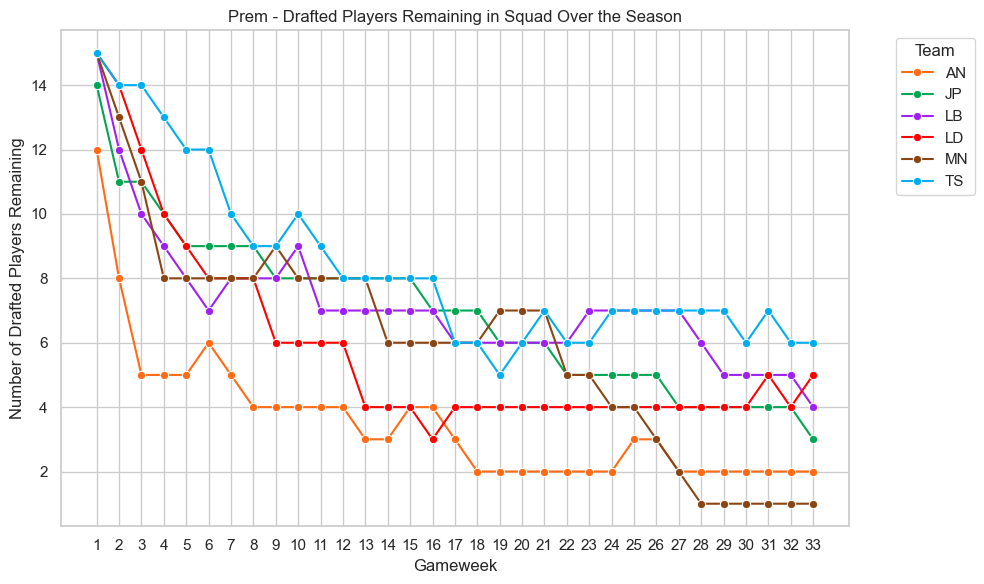

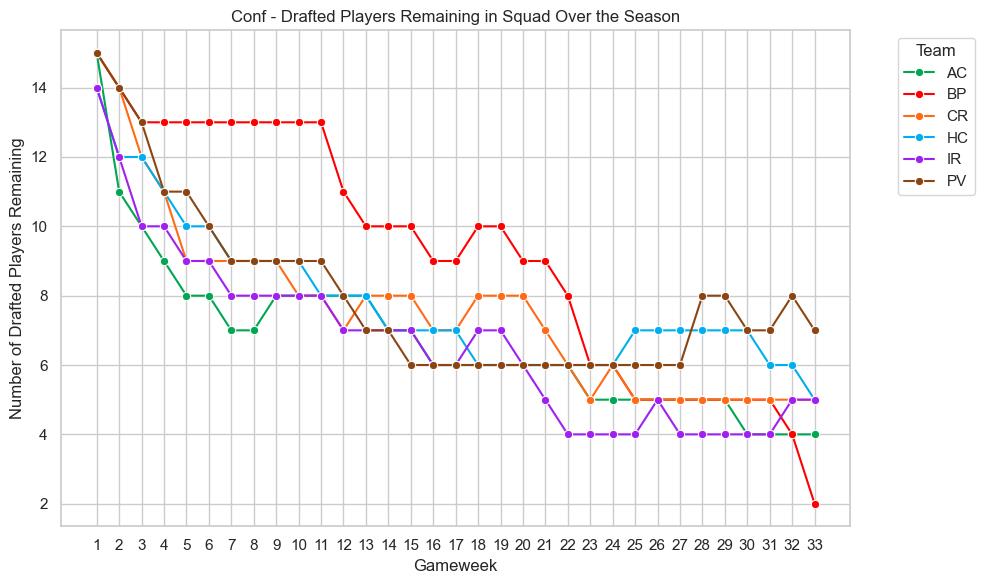

In [ ]:
# Plot draft players remaining in squad by week per short_name

def plot_draft_players_remaining(weekly_summary, choose_league, current_week, colour_palette ,save_path=None):
    weekly_summary_league = weekly_summary[weekly_summary['league_code'] == choose_league]
    draft_counts = weekly_summary_league.groupby(['short_name', 'gameweek'])['in_original_draft'].sum().reset_index()   

    plt.figure(figsize=(10, 6))
    import seaborn as sns
    sns.lineplot(
        data=draft_counts,
        x='gameweek',
        y='in_original_draft',
        hue='short_name',
        palette=colour_palette,
        marker='o'
    )
    plt.title(f'{choose_league} - Drafted Players Remaining in Squad Over the Season')
    plt.xlabel('Gameweek')
    plt.ylabel('Number of Drafted Players Remaining')
    plt.xticks(range(1, current_week + 1))
    # plt.ylim(0, draft_players.shape[0] + 1)
    plt.legend(title='Team', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    # Save or show
    if save_path:
        filename = f"draft_players_remaining_{choose_league}_GW{current_week}.png"
        if os.path.exists(filename):
            os.remove(filename)
        plt.savefig(filename, bbox_inches="tight")
    # else:
    plt.show()

    plt.close()

for league in ['Prem','Conf']:
    plot_draft_players_remaining(weekly_summary, league, current_week, colour_palette, save_path = True)

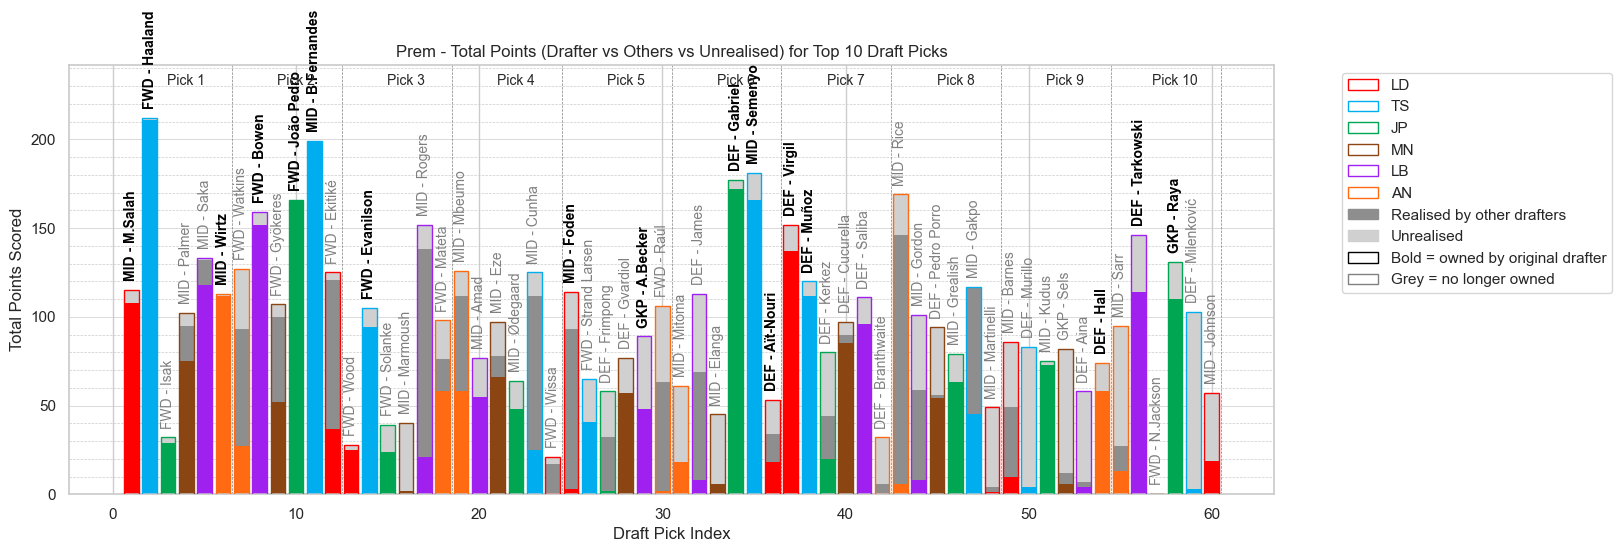

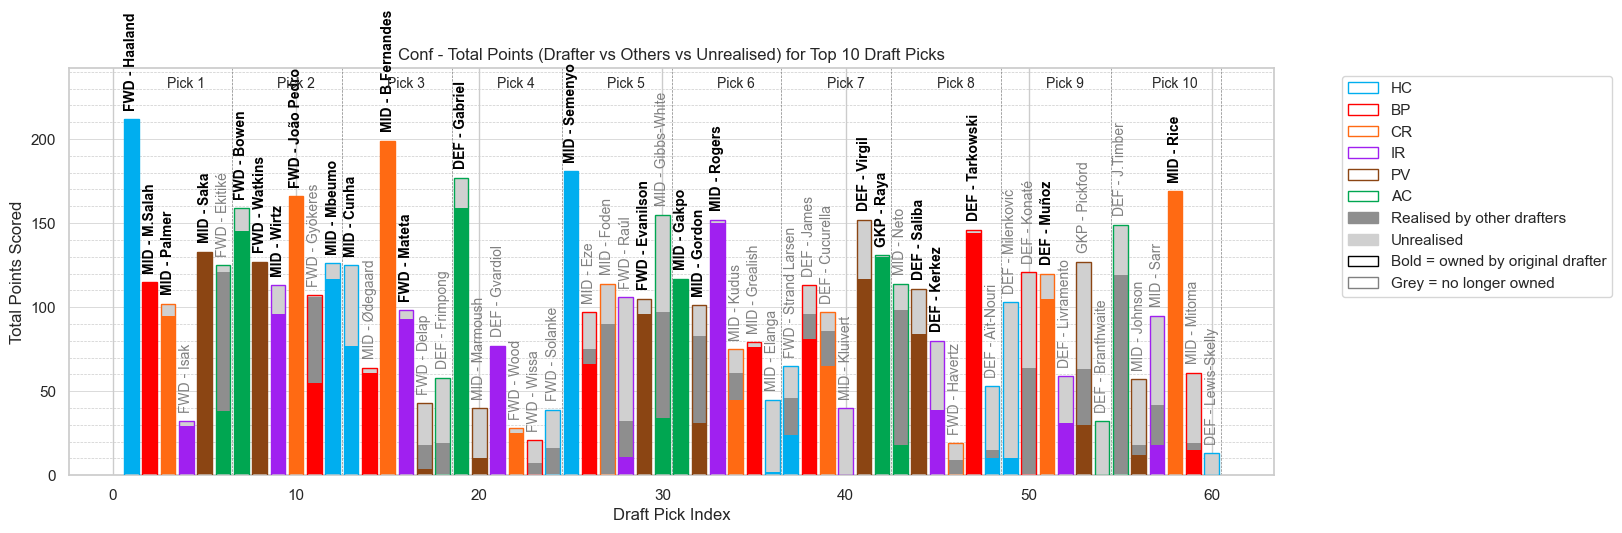

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

def plot_draft_pick_perf_realised_outline_with_other(
    player_points_weekly,
    weekly_summary,
    choose_league,
    choose_top_n,
    current_week,
    save_path=None,
    outline_width=1.8,
    realised_other_colour="#8E8E8E",
    unrealised_colour="#D0D0D0",
):
    # 1) Realised points by (league_code, short_name, id)
    realised_by_player = (
        weekly_summary
        .groupby(["league_code", "short_name", "id"])["points_scored"]
        .sum()
        .reset_index(name="points_realised_by_drafter")
    )

    # 2) Total realised points by anyone (league_code, id)
    realised_total = (
        weekly_summary
        .groupby(["league_code", "id"])["points_scored"]
        .sum()
        .reset_index(name="points_realised_total")
    )

    # 3) Draft pick totals
    draft_picks = (
        player_points_weekly[~player_points_weekly["draft_index"].isna()]
        .groupby(["league_code", "drafter_name", "web_name", "position", "draft_index", "id"])["total_points"]
        .sum()
        .reset_index()
    )
    draft_picks["Player"] = draft_picks["position"] + " - " + draft_picks["web_name"]

    # 4) Join realised tables
    # Assumes drafter_name == weekly_summary.short_name
    dp = draft_picks.merge(
        realised_by_player[["league_code", "short_name", "id", "points_realised_by_drafter"]],
        left_on=["league_code", "drafter_name", "id"],
        right_on=["league_code", "short_name", "id"],
        how="left",
    ).merge(
        realised_total[["league_code", "id", "points_realised_total"]],
        on=["league_code", "id"],
        how="left",
    )

    dp["points_realised_by_drafter"] = dp["points_realised_by_drafter"].fillna(0)
    dp["points_realised_total"] = dp["points_realised_total"].fillna(0)

    # Clamp to keep stacks sane
    dp["points_realised_total"] = np.minimum(dp["points_realised_total"], dp["total_points"])
    dp["points_realised_by_drafter"] = np.minimum(dp["points_realised_by_drafter"], dp["points_realised_total"])

    dp["points_realised_by_other"] = (dp["points_realised_total"] - dp["points_realised_by_drafter"]).clip(lower=0)
    dp["points_unrealised"] = (dp["total_points"] - dp["points_realised_total"]).clip(lower=0)

    # 5) Determine current ownership (GW == current_week)
    # If multiple rows exist per (league_code, id) in that GW, we just take the first.
    current_owner = (
        weekly_summary.loc[weekly_summary["gameweek"] == current_week, ["league_code", "short_name", "id"]]
        .dropna(subset=["league_code", "short_name", "id"])
        .drop_duplicates(subset=["league_code", "id"], keep="first")
        .rename(columns={"short_name": "current_owner"})
    )

    dp = dp.merge(current_owner, on=["league_code", "id"], how="left")
    dp["still_owned"] = dp["current_owner"].eq(dp["drafter_name"])  # True if still with original drafter

    # 6) Filter league, sort, reindex draft_index to consecutive
    dp_league = dp[dp["league_code"] == choose_league].copy()
    dp_league = dp_league.sort_values(by=["draft_index"])

    if dp_league.empty:
        print(f"No drafted picks found for league '{choose_league}'.")
        return

    no_players = dp_league["drafter_name"].nunique()
    dp_league["draft_index"] = range(1, len(dp_league) + 1)
    dp_league = dp_league[dp_league["draft_index"] <= choose_top_n * no_players].copy()

    if dp_league.empty:
        print(f"No drafted picks found for league '{choose_league}' after top-N filter.")
        return

    max_points = dp_league["total_points"].max()

    # 7) Colours for drafters (use your existing colour_palette)
    unique_drafters = list(dp_league["drafter_name"].unique())
    if isinstance(colour_palette, dict):
        drafter_to_colour = {d: colour_palette.get(d, "#4C72B0") for d in unique_drafters}
    else:
        pal = sns.color_palette(colour_palette, n_colors=len(unique_drafters))
        drafter_to_colour = dict(zip(unique_drafters, pal))

    bar_colours = [drafter_to_colour[d] for d in dp_league["drafter_name"].values]

    # 8) Plot
    plt.figure(figsize=(13, 6))

    x = dp_league["draft_index"].values
    realised_d = dp_league["points_realised_by_drafter"].values
    realised_o = dp_league["points_realised_by_other"].values
    unrealised = dp_league["points_unrealised"].values
    totals = dp_league["total_points"].values

    # Stacked fills
    plt.bar(x, realised_d, color=bar_colours, edgecolor="none")
    plt.bar(x, realised_o, bottom=realised_d, color=realised_other_colour, edgecolor="none")
    plt.bar(x, unrealised, bottom=(realised_d + realised_o), color=unrealised_colour, edgecolor="none")

    # Outline whole bar with drafter colour (so drafter is always obvious)
    for xi, total, col in zip(x, totals, bar_colours):
        plt.bar(
            xi,
            total,
            bottom=0,
            width=0.8,
            fill=False,
            edgecolor=col,
            linewidth=outline_width,
            zorder=6
        )

    plt.title(f"{choose_league} - Total Points (Drafter vs Others vs Unrealised) for Top {choose_top_n} Draft Picks")
    plt.xlabel("Draft Pick Index")
    plt.ylabel("Total Points Scored")

    # Player labels: bold+black if still owned, grey if not
    for _, row in dp_league.iterrows():
        label_colour = "black" if bool(row["still_owned"]) else "grey"
        label_weight = "bold" if bool(row["still_owned"]) else "normal"
        plt.text(
            row["draft_index"],
            row["total_points"] + 5,
            row["Player"],
            rotation=90,
            ha="center",
            va="bottom",
            fontsize=10,
            color=label_colour,
            fontweight=label_weight
        )

    # Vertical separators + Pick labels
    for i in range(1, choose_top_n + 1):
        plt.axvline(x=i * no_players + 0.5, color="grey", linestyle="--", linewidth=0.5)
        plt.text((i - 0.5) * no_players + 1, max_points + 25, f"Pick {i}", ha="center", va="top", fontsize=10)

    # Horizontal grid lines
    plt.gca().yaxis.set_minor_locator(plt.MultipleLocator(10))
    plt.gca().yaxis.grid(True, which="minor", linestyle="--", linewidth=0.5)
    plt.gca().yaxis.grid(True, which="major", linestyle="-", linewidth=0.5)

    plt.tight_layout()
    plt.ylim(0, max_points + 30)

    # Legend (+ ownership cue)
    handles = [
        mpatches.Patch(facecolor="none", edgecolor=drafter_to_colour[d], linewidth=outline_width, label=d)
        for d in unique_drafters
    ]
    handles += [
        mpatches.Patch(color=realised_other_colour, label="Realised by other drafters"),
        mpatches.Patch(color=unrealised_colour, label="Unrealised"),
        mpatches.Patch(facecolor="white", edgecolor="black", label="Bold = owned by original drafter"),
        mpatches.Patch(facecolor="white", edgecolor="grey", label="Grey = no longer owned"),
    ]
    plt.legend(handles=handles, title=None, bbox_to_anchor=(1.05, 1), loc="upper left")

    if save_path:
        filename = f"draft_picks_{choose_league}_GW{current_week}_realised_outline_other_owned.png"
        if os.path.exists(filename):
            os.remove(filename)
        plt.savefig(filename, bbox_inches="tight")

    plt.show()
    plt.close()

for league in ['Prem','Conf']:
    plot_draft_pick_perf_realised_outline_with_other(
        player_points_weekly,
        weekly_summary,
        choose_league=league,
        choose_top_n=10,
        current_week=current_week,
        save_path=True,
        outline_width=1.0
    )

In [ ]:
# draft_summary = pd.DataFrame(draft_picks.groupby(["league_code","short_name"])["total_points"].sum())
draft_summary = player_points_weekly.groupby(['league_code', 'drafter_name'])['total_points'].sum().reset_index()
draft_summary = draft_summary.rename(columns={'drafter_name': 'short_name'})
# weekly_summary['draft_points'] = np.where(weekly_summary['in_original_draft'] == 1, weekly_summary['points_scored'], 0)
# draft_summary = weekly_summary[weekly_summary['gameweek'] <= current_week].groupby(['league_code', 'short_name'])['draft_points'].sum().reset_index()
agg_summary = weekly_summary.groupby(['league_code' , 'short_name'])[['total_points', 'optimal_points', 'points_before_auto_subs', 'points_scored']].sum().reset_index()

agg_summary = agg_summary.merge(draft_summary, on = ['league_code', 'short_name'])
agg_summary.rename(columns = {'total_points_y' : 'draft_points', 'total_points_x': 'squad_points'}, inplace = True)
agg_summary['points_gained_through_waivers'] = agg_summary['squad_points'] - agg_summary['draft_points']
agg_summary['bench_strength'] = agg_summary['optimal_points'] - agg_summary['squad_points']
agg_summary['points_lost_choosing_starting_XI'] = agg_summary['points_before_auto_subs'] - agg_summary['optimal_points']
agg_summary['points_gained_with_auto_subs'] = agg_summary['points_scored'] - agg_summary['points_before_auto_subs']
agg_summary['net_points_lost_through_subs'] = agg_summary['points_scored'] - agg_summary['optimal_points']
agg_summary = agg_summary[['league_code', 'short_name', 'draft_points', 'points_gained_through_waivers', 'squad_points', 'bench_strength', 'optimal_points', 'points_lost_choosing_starting_XI', 'points_before_auto_subs', 'points_gained_with_auto_subs', 'net_points_lost_through_subs', 'points_scored']]
agg_summary = agg_summary.sort_values(by=['league_code', 'points_scored'], ascending=[False,False])
agg_summary


,league_code,short_name,draft_points,points_gained_through_waivers,squad_points,bench_strength,optimal_points,points_lost_choosing_starting_XI,points_before_auto_subs,points_gained_with_auto_subs,net_points_lost_through_subs,points_scored
11,Prem,TS,1907,59,1966,-139.0,1827.0,-203.0,1624,26,-177.0,1650
8,Prem,LB,1523,326,1849,-127.0,1722.0,-258.0,1464,75,-183.0,1539
7,Prem,JP,1243,526,1769,-94.0,1675.0,-204.0,1471,64,-140.0,1535
6,Prem,AN,1238,484,1722,-140.0,1582.0,-208.0,1374,45,-163.0,1419
10,Prem,MN,1244,448,1692,-101.0,1591.0,-270.0,1321,87,-183.0,1408
9,Prem,LD,1179,444,1623,-100.0,1523.0,-224.0,1299,59,-165.0,1358
2,Conf,CR,1575,245,1820,-104.0,1716.0,-207.0,1509,68,-139.0,1577
0,Conf,AC,1562,242,1804,-107.0,1697.0,-186.0,1511,39,-147.0,1550
5,Conf,PV,1482,331,1813,-113.0,1700.0,-270.0,1430,77,-193.0,1507
3,Conf,HC,1316,327,1643,-50.0,1593.0,-160.0,1433,47,-113.0,1480


In [ ]:
draft_summary = (
    player_points_weekly.groupby(["league_code", "drafter_name"])["total_points"].sum().reset_index()
)
draft_summary.rename(columns={"drafter_name": "short_name"}, inplace=True)
agg_summary = (
    weekly_summary.groupby(["league_code", "short_name"])[
        ["total_points", "optimal_points", "points_before_auto_subs", "points_scored"]
    ]
    .sum()
    .reset_index()
)

# Merge draft info
agg_summary = agg_summary.merge(draft_summary, on=["league_code", "short_name"])

# Compute derived metrics
agg_summary.rename(
    columns={"total_points_y": "draft_points", "total_points_x": "squad_points"},
    inplace=True,
)
agg_summary["points_gained_through_waivers"] = (
    agg_summary["squad_points"] - agg_summary["draft_points"]
)
agg_summary["bench_strength"] = (
    agg_summary["optimal_points"] - agg_summary["squad_points"]
)
agg_summary["points_lost_choosing_starting_XI"] = (
    agg_summary["points_before_auto_subs"] - agg_summary["optimal_points"]
)
agg_summary["points_gained_with_auto_subs"] = (
    agg_summary["points_scored"] - agg_summary["points_before_auto_subs"]
)
agg_summary["net_points_lost_through_subs"] = (
    agg_summary["points_scored"] - agg_summary["optimal_points"]
)

# Reorder columns
agg_summary = agg_summary[
    [
        "league_code",
        "short_name",
        "draft_points",
        "points_gained_through_waivers",
        "squad_points",
        "bench_strength",
        "optimal_points",
        "points_lost_choosing_starting_XI",
        "points_before_auto_subs",
        "points_gained_with_auto_subs",
        "net_points_lost_through_subs",
        "points_scored",
    ]
]

# Sort by league then points
agg_summary.sort_values(by=["league_code", "points_scored"], ascending=[False, False], inplace=True)
agg_summary.reset_index(drop=True, inplace=True)

agg_summary["draft_points"] = pd.to_numeric(agg_summary["draft_points"])
agg_summary["points_gained_through_waivers"] = pd.to_numeric(agg_summary['points_gained_through_waivers'])
agg_summary["squad_points"] = pd.to_numeric(agg_summary['squad_points'])
agg_summary["bench_strength"] = pd.to_numeric(agg_summary['bench_strength'])
agg_summary["optimal_points"] = pd.to_numeric(agg_summary['optimal_points'])
agg_summary["points_lost_choosing_starting_XI"] = pd.to_numeric(agg_summary['points_lost_choosing_starting_XI'])
agg_summary["points_before_auto_subs"] = pd.to_numeric(agg_summary['points_before_auto_subs'])
agg_summary["points_gained_with_auto_subs"] = pd.to_numeric(agg_summary['points_gained_with_auto_subs'])
agg_summary["net_points_lost_through_subs"] = pd.to_numeric(agg_summary['net_points_lost_through_subs'])
agg_summary["points_scored"] = pd.to_numeric(agg_summary['points_scored'])

# ---- 👇 ADD LEAGUE AVERAGE ROWS ----
# Compute averages for each league
league_avgs = (
    agg_summary.groupby("league_code")
    .mean(numeric_only=True)
    #.round(0)  # round for readability
    .reset_index()
)

# Round numeric columns only, cast to int
for col in league_avgs.select_dtypes(include="number").columns:
    league_avgs[col] = league_avgs[col].round(0).astype(int)


# Give them readable names
league_avgs["short_name"] = league_avgs["league_code"].replace(
    {"Prem": "Prem_Avg", "Conf": "Conf_Avg"}
)

# Align column order
league_avgs = league_avgs[agg_summary.columns]

# Sort by short_name
league_avgs.sort_values(by="short_name", ascending=False, inplace=True)

# Append them
agg_summary = pd.concat([agg_summary, league_avgs], ignore_index=True)

# Ensure convert columns to integers
for col in ['draft_points', 'points_gained_through_waivers', 'squad_points', 'bench_strength', 'optimal_points', 'points_lost_choosing_starting_XI', 'points_before_auto_subs', 'points_gained_with_auto_subs', 'net_points_lost_through_subs', 'points_scored']:
    if col in agg_summary.columns:
        agg_summary[col] = agg_summary[col].astype(int)

print(agg_summary)


   league_code short_name  draft_points  points_gained_through_waivers  \
0         Prem         TS          1907                             59   
1         Prem         LB          1523                            326   
2         Prem         JP          1243                            526   
3         Prem         AN          1238                            484   
4         Prem         MN          1244                            448   
5         Prem         LD          1179                            444   
6         Conf         CR          1575                            245   
7         Conf         AC          1562                            242   
8         Conf         PV          1482                            331   
9         Conf         HC          1316                            327   
10        Conf         IR          1296                            485   
11        Conf         BP          1435                            118   
12        Prem   Prem_Avg          138

In [ ]:
# Starting formation vs optimal formation

starting_formation = weekly_summary.groupby(['league_code', 'short_name', 'gameweek', 'position'])['originally_starting'].sum().reset_index()
starting_formation = starting_formation[starting_formation['position'] != 'GKP']
starting_formation_summary = starting_formation.pivot_table(index=['league_code', 'short_name', 'gameweek'], columns='position', values='originally_starting', fill_value=0).reset_index()
starting_formation_summary['formation'] = starting_formation_summary['DEF'].astype(int).astype(str) + '-' + starting_formation_summary['MID'].astype(int).astype(str) + '-' + starting_formation_summary['FWD'].astype(int).astype(str)

# Count formations by league_code, short_name
formation_counts = starting_formation_summary.groupby(['league_code', 'short_name', 'formation']).size().reset_index(name='count')

# Pivot so formations across the top
formation_pivot = formation_counts.pivot_table(index=['league_code', 'short_name'], columns='formation', values='count', fill_value=0).reset_index()
# print(formation_pivot)

# Do the same for optimal formation
weekly_summary['optimal_weight'] = weekly_summary['optimal_points'] / weekly_summary['total_points']
optimal_formation = weekly_summary.groupby(['league_code', 'short_name', 'gameweek', 'position'])['optimal_weight'].sum().reset_index()
optimal_formation = optimal_formation[optimal_formation['position'] != 'GKP']
# print(optimal_formation)
optimal_formation_counts = optimal_formation.groupby(['league_code', 'short_name', 'position'])['optimal_weight'].mean().reset_index()
optimal_formation_pivot = optimal_formation_counts.pivot_table(index=['league_code', 'short_name'], columns='position', values='optimal_weight', fill_value=0).reset_index()
# print(optimal_formation_pivot)
optimal_formation_pivot['optimal_formation'] = (
    (optimal_formation_pivot['DEF']).round(1).astype(str) + '-' +
    (optimal_formation_pivot['MID']).round(1).astype(str) + '-' +
    (optimal_formation_pivot['FWD']).round(1).astype(str)
)
formation_comparison = formation_pivot.merge(optimal_formation_pivot[['league_code', 'short_name', 'optimal_formation']], on=['league_code', 'short_name'])

# Convert to integers
for col in ['3-4-3', '3-5-2', '4-3-3', '4-4-2', '4-5-1', '5-2-3', '5-3-2', '5-4-1']:
    if col in formation_comparison.columns:
        formation_comparison[col] = formation_comparison[col].astype(int)

formation_comparison.sort_values(by=['league_code', 'short_name'], ascending = [False, True], inplace=True)
formation_comparison

C:\Users\MikeNelson\AppData\Local\Temp\ipykernel_4120\17301979.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  starting_formation_summary = starting_formation.pivot_table(index=['league_code', 'short_name', 'gameweek'], columns='position', values='originally_starting', fill_value=0).reset_index()


,league_code,short_name,3-4-3,3-5-2,4-3-3,4-4-2,4-5-1,5-2-3,5-3-2,5-4-1,optimal_formation
6,Prem,AN,17,14,1,1,0,0,0,0,3.6-4.1-2.2
7,Prem,JP,14,5,5,9,0,0,0,0,3.5-4.0-2.3
8,Prem,LB,15,7,4,1,0,3,2,1,3.5-4.0-2.4
9,Prem,LD,9,12,4,4,4,0,0,0,3.7-3.9-2.2
10,Prem,MN,2,5,2,11,6,0,1,6,3.6-4.0-2.2
11,Prem,TS,14,11,4,4,0,0,0,0,3.6-3.9-2.4
0,Conf,AC,12,9,6,5,1,0,0,0,3.4-4.0-2.5
1,Conf,BP,4,4,4,9,6,0,2,4,3.9-3.5-2.2
2,Conf,CR,11,6,3,9,4,0,0,0,3.6-4.0-2.2
3,Conf,HC,2,3,9,17,0,0,2,0,3.3-4.2-2.2


In [ ]:
top_n = 10
last_x_weeks = 8
player_points_total_points = player_points_weekly.groupby(['league_code', 'id'])['total_points'].sum().reset_index().rename(columns={'total_points': 'league_total_points'})
player_points_total_points['league_total_points_rank'] = player_points_total_points.groupby(['league_code'])['league_total_points'].rank(ascending=False, method='min').astype(int)
player_points_weekly_edit = player_points_weekly.merge(player_points_total_points, on=['league_code', 'id'])
player_points_weekly_edit['Player Name'] = player_points_weekly_edit['position'] + ' - ' + player_points_weekly_edit['web_name'] + ' (' + player_points_weekly_edit['team_name'] + ')'
player_points_weekly_edit['Owner_Score'] = player_points_weekly_edit['short_name'] + ' - ' + player_points_weekly_edit['total_points'].astype(str)
# Pivot so rank, player name, drafter_name down the side then gameweeks across the top, then short_name as values

player_points_weekly_edit = player_points_weekly_edit[player_points_weekly_edit['gameweek'] > (current_week - last_x_weeks)]
player_points_pivot = player_points_weekly_edit.pivot_table(index=['league_code', 'league_total_points_rank', 'league_total_points', 'Player Name', 'drafter_name'], columns='gameweek', values='Owner_Score', fill_value='', aggfunc='first').reset_index()
player_points_pivot_topn = player_points_pivot.sort_values(by=['league_total_points', 'Player Name', 'league_code'], ascending=[False, True, False]).head(top_n*2)
player_points_pivot_topn

gameweek,league_code,league_total_points_rank,league_total_points,Player Name,drafter_name,26,27,28,29,30,31,32,33
829,Prem,1,212,FWD - Haaland (MCI),TS,TS - 5,TS - 6,TS (Benched) - 0,TS - 2,TS - 2,TS (Benched) - 0,TS - 2,TS - 13
0,Conf,1,212,FWD - Haaland (MCI),HC,HC - 5,HC - 6,HC (Benched) - 0,HC - 2,HC - 2,HC - 0,HC - 2,HC - 13
830,Prem,2,199,MID - B.Fernandes (MUN),TS,TS - 2,TS - 2,TS - 13,TS - 8,TS - 10,TS - 13,TS - 4,TS - 6
1,Conf,2,199,MID - B.Fernandes (MUN),CR,CR - 2,CR - 2,CR - 13,CR - 8,CR - 10,CR - 13,CR - 4,CR - 6
831,Prem,3,181,MID - Semenyo (MCI),TS,TS - 14,TS - 4,TS - 8,TS - 7,TS - 2,TS - 0,TS - 2,TS - 5
2,Conf,3,181,MID - Semenyo (MCI),HC,HC - 14,HC - 4,HC - 8,HC - 7,HC - 2,HC (Benched) - 0,HC - 2,HC - 5
832,Prem,4,177,DEF - Gabriel (ARS),JP,JP - 7,JP - 2,JP - 9,JP - 11,JP - 9,JP (Benched) - 0,JP (Benched) - 4,JP (Benched) - 0
3,Conf,4,177,DEF - Gabriel (ARS),AC,AC - 7,AC - 2,AC - 9,AC - 11,AC - 9,AC (Benched) - 0,AC - 4,AC (Benched) - 0
833,Prem,5,169,MID - Rice (ARS),AN,MN - 14,MN - 4,MN - 5,MN - 3,MN - 3,MN (Benched) - 0,MN - 4,MN - 2
4,Conf,5,169,MID - Rice (ARS),CR,CR - 14,CR - 4,CR - 5,CR - 3,CR - 3,CR (Benched) - 0,CR - 4,CR - 2


In [ ]:
import pandas as pd

# Filter for current week
weekly_summary_current = weekly_summary[weekly_summary['gameweek'] == current_week]

# Split into Prem and Conf for current week
prem_current = weekly_summary_current[weekly_summary_current['league_code'] == 'Prem']
conf_current = weekly_summary_current[weekly_summary_current['league_code'] == 'Conf']

# Compute total points across *all* weeks (not just current week)
prem_total_points = (
    weekly_summary[weekly_summary['league_code'] == 'Prem']
    .groupby('short_name')['points_scored']
    .sum()
    .sort_values(ascending=False)
)

conf_total_points = (
    weekly_summary[weekly_summary['league_code'] == 'Conf']
    .groupby('short_name')['points_scored']
    .sum()
    .sort_values(ascending=False)
)

# Define ordering by total season points
prem_order = prem_total_points.index.tolist()
conf_order = conf_total_points.index.tolist()

# Define overlap count for current week only
def overlap_count(prem_team, conf_team):
    prem_players = set(prem_current.loc[prem_current['short_name'] == prem_team, 'web_name'])
    conf_players = set(conf_current.loc[conf_current['short_name'] == conf_team, 'web_name'])
    return len(prem_players & conf_players)

# Build overlap matrix
overlap_matrix = pd.DataFrame(
    [[overlap_count(prem_team, conf_team) for prem_team in prem_order] for conf_team in conf_order],
    index=conf_order,
    columns=prem_order
)

# Optional: Pretty display in Jupyter
overlap_matrix.style.background_gradient(cmap="Blues")



,TS,LB,JP,AN,MN,LD
CR,2,2,1,1,4,2
AC,3,3,2,1,3,1
PV,1,1,4,1,2,3
HC,4,1,0,3,0,1
IR,2,1,4,2,2,0
BP,2,1,1,1,1,3


In [ ]:
import pandas as pd
import base64
from datetime import datetime
from pathlib import Path

# ------------------------------------------------
# 🖌️ STYLING FUNCTIONS
# ------------------------------------------------

def style_prem_table(df: pd.DataFrame):
    df = df.reset_index(drop=True)
    max_gw_points = df["GW Points"].max() if "GW Points" in df.columns else None

    def highlight_rows(row):
        pos = row.name
        styles = [''] * len(row)

        # Highlight highest GW Points
        if max_gw_points is not None and row["GW Points"] == max_gw_points:
            styles[df.columns.get_loc("GW Points")] = 'background-color: #fff6b2; font-weight: bold'

        # Horizontal lines
        if pos == 0:  # winner
            styles = ['border-bottom: 3px solid black'] * len(row)
        elif pos == len(df) - 2:  # 19th place
            styles = ['border-top: 3px solid red'] * len(row)

        return styles

    return df.style.apply(highlight_rows, axis=1).format(precision=1, na_rep='')


def style_conf_table(df: pd.DataFrame):
    df = df.reset_index(drop=True)
    max_gw_points = df["GW Points"].max() if "GW Points" in df.columns else None
    # print(max_gw_points)

    def highlight_rows(row):
        pos = row.name
        styles = [''] * len(row)

        if max_gw_points is not None and row["GW Points"] == max_gw_points:
            styles[df.columns.get_loc("GW Points")] = 'background-color: #fff6b2; font-weight: bold'
            # print("Highlighting row:", row['Name'])

        if pos == 1:  # promotion cutoff
            styles = ['border-bottom: 3px solid green'] * len(row)
        elif pos == len(df) - 1:  # last place
            styles = ['border-top: 3px solid orange'] * len(row)

        return styles

    return df.style.apply(highlight_rows, axis=1).format(precision=1, na_rep='')


def style_league_h2h(df: pd.DataFrame):
    def highlight_winner(row):
        styles = [''] * len(row)
        if row['GW'] == 'Running Total':
            styles = ['background-color: #f0f0f0; font-weight: bold'] * len(row)
        if row['Prem Points'] > row['Conf Points']:
            styles[df.columns.get_loc('Prem Points')] = 'background-color: lightgreen; font-weight: bold'
            styles[df.columns.get_loc('Prem - Win')] = 'background-color: lightgreen; font-weight: bold'
        elif row['Conf Points'] > row['Prem Points']:
            styles[df.columns.get_loc('Conf Points')] = 'background-color: lightgreen; font-weight: bold'
            styles[df.columns.get_loc('Conf - Win')] = 'background-color: lightgreen; font-weight: bold'
        return styles

    return df.style.apply(highlight_winner, axis=1).format(precision=1, na_rep='')

def style_league_comparison(df: pd.DataFrame):
    df = df.reset_index(drop=True)

    def highlight_not_drafted(row):
        styles = [''] * len(row)
        for col in ["Prem", "Conf"]:
            if col in df.columns and row[col] != "Not Drafted":
                styles[df.columns.get_loc(col)] = 'background-color: #cce5ff; font-weight: bold'
        return styles

    return df.style.apply(highlight_not_drafted, axis=1).format(precision=1, na_rep='')

def style_league_split_table(df: pd.DataFrame, league_col: str = None,
                             line_css: str = "border-bottom: 3px solid black !important"):
    """Draw a horizontal separator between league sections (Prem → Conf)"""
    if league_col is None:
        league_col = "league_code" if "league_code" in df.columns else "League"

    df2 = df.reset_index(drop=True)
    split_mask = (
        (df2[league_col].ne(df2[league_col].shift(-1))) &
        (df2[league_col].notna()) &
        (df2.index < len(df2) - 1)
    )

    if df2[league_col].nunique() <= 1:
        split_mask[:] = False

    def _row_style(row: pd.Series):
        return [line_css] * len(row) if split_mask.iloc[row.name] else [''] * len(row)

    return df2.style.apply(_row_style, axis=1).format(precision=1, na_rep='')

def style_overlap(df):
    return df.style.background_gradient(cmap="Blues", axis=None)

import pandas as pd
import re

def style_top_players(
    df: pd.DataFrame,
    drafter_col: str = "Drafted By",
    benched_token: str = "(Benched)",

    not_drafted_css: str = "background-color: #f8d7da; color: #721c24;",
    mismatch_css: str = "background-color: #fff3cd; font-weight: bold;",
    benched_css: str = "background-color: #e0e0e0; color: #808080; font-style: italic;",
):
    df2 = df.reset_index(drop=True).copy()

    non_gw_cols = {
        "League", "Rank", "Points",
        "Player Name", drafter_col
    }
    gw_cols = [c for c in df2.columns if c not in non_gw_cols]

    drafter_init = (
        df2[drafter_col]
        .astype(str)
        .str.extract(r"^([A-Za-z]{2})", expand=False)
        .fillna("")
        .str.upper()
    )

    def _owner_init(val: object) -> str:
        if pd.isna(val):
            return ""
        m = re.match(r"^([A-Za-z]{2})", str(val))
        return m.group(1).upper() if m else ""

    def _style_cells(data: pd.DataFrame) -> pd.DataFrame:
        styles = pd.DataFrame("", index=data.index, columns=data.columns)

        for col in gw_cols:
            col_vals = data[col].astype(str)

            not_drafted = col_vals.str.startswith("Not Drafted", na=False)
            benched = col_vals.str.contains(re.escape(benched_token), na=False)

            owner_inits = col_vals.map(_owner_init)
            mismatch = (
                (owner_inits != drafter_init) &
                (owner_inits != "") &
                (drafter_init != "")
            )

            # precedence order
            styles.loc[not_drafted, col] = not_drafted_css
            styles.loc[~not_drafted & benched, col] = benched_css
            styles.loc[~not_drafted & ~benched & mismatch, col] = mismatch_css

        return styles

    return df2.style.apply(_style_cells, axis=None).format(na_rep="")


# ------------------------------------------------
# 🖼️ IMAGE HELPERS (Unified embed/link version)
# ------------------------------------------------

def insert_image(path: str, embed: bool = False) -> str:
    """Return an <img> tag. Embed if requested, otherwise reference the file."""
    if embed:
        with open(path, "rb") as img_file:
            encoded = base64.b64encode(img_file.read()).decode("utf-8")
        return f"<img src='data:image/png;base64,{encoded}' class='report-image'>"
    else:
        filename = Path(path).name
        return f"<img src='{filename}' class='report-image'>"


def insert_images_side_by_side(*paths, embed: bool = False) -> str:
    """Return a <div> with images side by side."""
    imgs = []
    for path in paths:
        if embed:
            with open(path, "rb") as img_file:
                encoded = base64.b64encode(img_file.read()).decode("utf-8")
            imgs.append(f"<img src='data:image/png;base64,{encoded}'>")
        else:
            filename = Path(path).name
            imgs.append(f"<img src='{filename}'>")
    return "<div class='chart-row'>" + "".join(imgs) + "</div>"


# ------------------------------------------------
# 🧾 REPORT GENERATION
# ------------------------------------------------

def generate_weekly_report(current_week, form_games,
                           prem_table_print, conf_table_print,
                           league_h2h_print, league_comparison,
                           impact_of_subs, transfers, trade_history, agg_summary, overlap_matrix,
                           fixtures, fixtures_by_team,
                           embed_images: bool = False):
    """Generate a weekly HTML report. Set embed_images=True for self-contained HTML."""

    html_header = f"""
    <html>
    <head>
        <meta charset="utf-8">
        <title>GW{current_week} Weekly Report</title>
        <style>
            body {{
                font-family: 'Segoe UI', Arial, sans-serif;
                margin: 40px;
                background-color: #f8f9fa;
                color: #212529;
            }}
            h1 {{
                text-align: center;
                margin-bottom: 40px;
            }}
            h2 {{
                border-bottom: 2px solid #dee2e6;
                padding-bottom: 4px;
                margin-top: 50px;
            }}
            h3 {{ margin-top: 30px; }}
            table {{
                width: 95%;
                margin: 20px auto;
                border-collapse: collapse;
                font-size: 14px;
            }}
            th {{
                background-color: #e9ecef;
                text-align: left;
                padding: 8px;
            }}
            td {{ padding: 8px; }}
            img.report-image {{
                display: block;
                margin: 30px auto;
                max-width: 95%;
                border-radius: 8px;
                box-shadow: 0 0 8px rgba(0,0,0,0.1);
            }}
            .nav {{
                position: fixed;
                top: 0; left: 0; right: 0;
                background-color: #343a40;
                padding: 10px 0;
                z-index: 999;
                text-align: center;
            }}
            .nav a {{
                color: white;
                text-decoration: none;
                margin: 0 15px;
                font-weight: 500;
            }}
            .nav a:hover {{ text-decoration: underline; }}
            .content {{ margin-top: 70px; }}
            .back-to-top {{
                text-align: right;
                width: 95%;
                margin: 0 auto;
            }}
            .chart-row {{
                display: flex;
                justify-content: center;
                flex-wrap: wrap;
                gap: 10px;
            }}
            .chart-row img {{
                width: 48%;
                border-radius: 8px;
                box-shadow: 0 0 8px rgba(0,0,0,0.1);
            }}
            .nav-buttons {{
                display: flex;
                justify-content: center;
                gap: 15px;
                margin: 40px 0 20px;
            }}
            .nav-buttons .btn {{
                background-color: #0d6efd;
                color: white;
                text-decoration: none;
                padding: 10px 18px;
                border-radius: 6px;
                font-weight: 500;
                transition: background-color 0.2s ease;
            }}
            .nav-buttons .btn:hover {{
                background-color: #0b5ed7;
            }}
        </style>
    </head>
    <body>
    <div class="nav">
        <a href="#prem">Premiership</a>
        <a href="#conf">Conference</a>
        <a href="#h2h">Head to Head</a>
        <a href="#gwpoints">Gameweek Points</a>
        <a href="#subs">Subs</a>
        <a href="#transfers">Transfers</a>
        <a href="#draft">Draft Picks</a>
        <a href="#season">Season Stats</a>
        <a href="#common">Players in Common</a>
        <a href="#results">Results</a>
    </div>
    <div class="content">
    <h1>Gameweek {current_week} Report</h1>
    """

    # ---------- NAVIGATION BUTTONS ----------
    prev_week = current_week - 1
    next_week = current_week + 1

    prev_link = f'<a href="weekly_report_GW{prev_week}.html" class="btn">← Previous Week</a>' if prev_week >= 1 else ''
    import os
    next_link = f'<a href="weekly_report_GW{next_week}.html" class="btn">Next Week →</a>' if os.path.exists(f"weekly_report_GW{next_week}.html") else ''

    # Build button HTML
    buttons_html = f"""
    <div class="nav-buttons">
        <a href="index.html" class="btn">← Back to Homepage</a>
        {prev_link}
        {next_link}
    </div>
    """

    html_footer = """
    <div class="back-to-top"><a href="#top">Back to top ↑</a></div>
    </div></body></html>
    """

    with open(f"weekly_report_GW{current_week}.html", "w", encoding="utf-8") as f:
        f.write(html_header)

        # ---------- PREMIER ----------
        f.write('<h2 id="prem">Premiership Table</h2>')
        prem_df = prem_table_print.drop(columns=["league_code"]).rename(columns={
            'rank': 'Rank', 'last_rank': 'Last Rank', 'name': 'Name',
            'entry_name': 'Team Name', 'gameweek_points': 'GW Points',
            'total': 'Total Points', 'form_points': f"Last {form_games} Avg",
            'form_rank': 'Form Rank', 'points_from_top': 'Pts from Top',
            'points_from_safety': 'Pts from Safety', 'points_above_relegation': 'Pts above Relegation'
        }).reset_index(drop=True)
        f.write(style_prem_table(prem_df).hide(axis="index").to_html())
        f.write(insert_images_side_by_side(
            f"cumulative_points_Prem_GW{current_week}.png",
            # f"gameweek_highs_lows_Prem_GW{current_week}.png",
            f"point_distribution_Prem_GW{current_week}.png",
            embed=embed_images
        ))

        # ---------- CONFERENCE ----------
        f.write('<h2 id="conf">Conference Table</h2>')
        conf_df = conf_table_print.drop(columns=["league_code"]).rename(columns={
            'rank': 'Rank', 'last_rank': 'Last Rank', 'name': 'Name',
            'entry_name': 'Team Name', 'gameweek_points': 'GW Points',
            'total': 'Total Points', 'form_points': f"Last {form_games} Avg",
            'form_rank': 'Form Rank', 'points_from_promotion': 'Pts from Promotion',
            'points_above_chicken_suit': 'Pts above Chicken Suit'
        }).reset_index(drop=True)
        f.write(style_conf_table(conf_df).hide(axis="index").to_html())
        f.write(insert_images_side_by_side(
            f"cumulative_points_Conf_GW{current_week}.png",
            # f"gameweek_highs_lows_Conf_GW{current_week}.png",
            f"point_distribution_Conf_GW{current_week}.png",
            embed=embed_images
        ))

        # ---------- H2H ----------
        f.write('<h2 id="h2h">Leagues Head to Head</h2>')
        f.write(style_league_h2h(league_h2h_print).hide(axis="index").to_html())
        f.write('<h3>Top scoring players not drafted</h3>')
        f.write(style_league_comparison(league_comparison[league_comparison['gameweek'] == current_week]
                .drop(columns=["gameweek"])
                .rename(columns={
                    "rank_in_week" : 'GW Rank', 
                    "player_name": "Player", 
                    "total_points": "Total Points"
                }))
                .hide(axis="index")
                .to_html(justify='left', classes=['table','table-striped','table-bordered']))

        # ---------- POINTS SUMMARIES ----------
        f.write('<h2 id="gwpoints">Points Summaries</h2>')
        f.write("<h3>Prem - Points Summary</h3>")
        f.write(insert_image(f"weekly_points_heatmap_Prem_GW{current_week}.png", embed=embed_images))
        f.write("<h3>Conf - Points Summary</h3>")
        f.write(insert_image(f"weekly_points_heatmap_Conf_GW{current_week}.png", embed=embed_images))

        # ---------- SUBSTITUTIONS ----------
        f.write('<h2 id="subs">Choice of Substitutions</h2>')
        # styled_subs = style_league_split_table(
        #     impact_of_subs.rename(columns={
        #         'league_code': 'League',
        #         'short_name': 'Name',
        #         'net_points_lost_through_subs': 'Net Points Lost in GW',
        #         'total_points_lost_through_subs': 'Total Points Lost in Season'
        #     }),
        #     league_col='League'
        # )
        # f.write(styled_subs.hide(axis="index").to_html(justify='left', classes=['table','table-striped','table-bordered']))
        f.write(insert_images_side_by_side(
            f"weekly_sub_points_barchart_Prem_GW{current_week}.png",
            # f"gameweek_highs_lows_Conf_GW{current_week}.png",
            f"weekly_sub_points_barchart_Conf_GW{current_week}.png",
            embed=embed_images
        ))

        # ---------- TRANSFERS ----------
        f.write('<h2 id="transfers">Transfer Activity</h2>')
        transfers_this_week = (
            transfers[(transfers['result'] == 'successful') & (transfers['gameweek'] == current_week)]
            .drop(columns=["date_added","element_in","element_out","index","priority","result",
                           "transfer_category","player_in_points_scored_in_week",
                           "player_out_points_scored_in_week","abs_net_trade","gameweek"])
            .rename(columns={
                'league_code': 'League', 'short_name': 'Name',
                'kind': 'Type', 'position': 'Position',
                'player_in': 'Player In (GW Points)',
                'player_out': 'Player Out (GW Points)',
                'net_points_of_transfer_in_week': 'Net Points from Transfer in GW'
            })
        )
        styled_transfers = style_league_split_table(transfers_this_week, league_col='League')
        f.write(styled_transfers.hide(axis="index").to_html(justify='left', classes=['table','table-striped','table-bordered']))
        f.write(insert_images_side_by_side(
            f"transfer_activity_Prem_GW{current_week}.png",
            f"transfer_activity_Conf_GW{current_week}.png",
            embed=embed_images
        ))

        # Unique players used plots
        f.write("<h3>Unique Players Used Over the Season</h3>")
        f.write(insert_images_side_by_side(
            f"unique_players_used_Prem_GW{current_week}.png",
            f"unique_players_used_Conf_GW{current_week}.png",
            embed=embed_images
        ))

        # ---------- TRADES ----------
        f.write('<h2>Trade History</h2>')
        styled_trades = style_league_split_table(
            trade_history[['league_code', 'GW traded', 'Points Since Trade', 'net_points_from_trade']].rename(columns={
                'league_code': 'League', 
                'net_points_from_trade': 'Net Points from Trade'
            }),
            league_col='League'
        )
        f.write(styled_trades.hide(axis="index").to_html(justify='left', classes=['table','table-striped','table-bordered'])) 

        # ---------- DRAFT ----------
        f.write('<h2 id="draft">Draft Pick Performance</h2>')
        f.write(insert_image(f"draft_picks_Prem_GW{current_week}_realised_outline_other_owned.png", embed=embed_images))
        f.write(insert_image(f"draft_picks_Conf_GW{current_week}_realised_outline_other_owned.png", embed=embed_images))

        # Players remaining in squad
        f.write("<h3>Drafted Players Remaining in Squad Over the Season</h3>")
        f.write(insert_images_side_by_side(
            f"draft_players_remaining_Prem_GW{current_week}.png",
            f"draft_players_remaining_Conf_GW{current_week}.png",
            embed=embed_images
        ))

        # ---------- SEASON SUMMARY ----------
        f.write('<h2 id="season">Season Summary</h2>')
        styled_agg = style_league_split_table(
            agg_summary.drop(columns=['points_before_auto_subs']).rename(columns={
                'league_code': 'League', 'short_name': 'Name',
                'draft_points': 'Draft Points', 'points_gained_through_waivers': 'Transfer Points',
                'squad_points': 'Squad Points', 'bench_strength': 'Bench Strength',
                'optimal_points': 'Optimal Points', 'points_lost_choosing_starting_XI': 'Lost choosing Starting XI',
                'points_gained_with_auto_subs': 'Gained with Auto', 'net_points_lost_through_subs': 'Net Sub Points',
                'points_scored': 'League Total'
            }),
            league_col='League'
        )
        f.write(styled_agg.hide(axis="index").to_html(justify='left', classes=['table','table-striped','table-bordered']))

        # Top N players points table
        f.write(f"<h3>Top {top_n} Players by Total Points Scored (Last {last_x_weeks} Weeks)</h3>")
        styled_topn = style_top_players(player_points_pivot_topn.rename(columns={
            'league_code': 'League', 'league_total_points_rank': 'Rank',
            'league_total_points': 'Points', 
            'drafter_name': 'Drafted By'
        }))
        f.write(styled_topn.hide(axis="index").to_html(justify='left', classes=['table','table-striped','table-bordered']))

        # Heatmap for formation comparison
        # formation_comparison
        f.write("<h3>Chosen starting formation</h3>")
        # styled_formation = style_league_split_table(
        #     formation_comparison.rename(columns={
        #         'league_code': 'League', 'short_name': 'Name',
        #         # '3-4-3': '3-4-3 Count', '3-5-2': '3-5-2 Count', '4-3-3': '4-3-3 Count',
        #         # '4-4-2': '4-4-2 Count', '4-5-1': '4-5-1 Count', '5-4-1': '5-4-1 Count',
        #         'optimal_formation': 'Optimal Formation'
        #     }),
        #     league_col='League'
        # )
        # f.write(styled_formation.hide(axis="index").to_html(justify='left', classes=['table','table-striped','table-bordered']))

        if current_week >= 15:
            styled_formation_2 = style_overlap(
                formation_comparison.rename(columns={
                    'league_code': 'League', 'short_name': 'Name', 'optimal_formation': 'Avg Optimal Scoring Formation'})
                .set_index(['League', 'Name', 'Avg Optimal Scoring Formation'])[['3-4-3', '3-5-2', '4-3-3', '4-4-2', '4-5-1', '5-2-3', '5-3-2', '5-4-1']]
                # .set_index(['League', 'Name', 'Avg Optimal Scoring Formation'])[['3-4-3', '3-5-2', '4-3-3', '4-4-2', '4-5-1', '5-3-2', '5-4-1']]
            )
        else:
            styled_formation_2 = style_overlap(
                formation_comparison.rename(columns={
                    'league_code': 'League', 'short_name': 'Name', 'optimal_formation': 'Avg Optimal Scoring Formation'})
                # .set_index(['League', 'Name', 'Avg Optimal Scoring Formation'])[['3-4-3', '3-5-2', '4-3-3', '4-4-2', '4-5-1', '5-2-3', '5-3-2', '5-4-1']]
                .set_index(['League', 'Name', 'Avg Optimal Scoring Formation'])[['3-4-3', '3-5-2', '4-3-3', '4-4-2', '4-5-1', '5-3-2', '5-4-1']]
            )
        f.write(styled_formation_2.to_html(justify='left', classes=['table','table-striped','table-bordered']))

        f.write("<h2>Team Points Distribution</h2>")
        f.write(insert_images_side_by_side(
            f"heatmap_team_name_Prem_GW{current_week}.png",
            f"heatmap_team_name_Conf_GW{current_week}.png",
            embed=embed_images
        ))
        f.write("<h2>Position Points Distribution</h2>")
        f.write(insert_images_side_by_side(
            f"heatmap_position_Prem_GW{current_week}.png",
            f"heatmap_position_Conf_GW{current_week}.png",
            embed=embed_images
        ))

        f.write('<h2 id="common">Player Overlap Matrix</h2>')
        styled_overlap = style_overlap(overlap_matrix)
        f.write(styled_overlap.to_html())

        # ---------- THIS WEEK'S FIXTURES (pretty) ----------
        f.write(f'<h2 id="results">GW{current_week} Results & Next Fixtures</h2>')

        # ---------- FIXTURES + NEXT 6 SIDE-BY-SIDE (copy/paste block) ----------
        # Assumes you already have:
        #   - fixtures2 (with columns: event, kickoff_time, team_h, team_a, team_h_score, team_a_score, team_h_difficulty, team_a_difficulty)
        #   - team_gw (with columns: gameweek, team, opposition, home_away, team_difficulty) and team/opposition are 3-letter codes
        #   - current_week (int)
        # import pandas as pd

        # ====== Build "This Week" pretty fixture list (grouped by day) ======
        this_week_fx = fixtures.loc[fixtures["event"] == current_week].copy()
        this_week_fx["kickoff_time"] = pd.to_datetime(this_week_fx["kickoff_time"], utc=True, errors="coerce")
        this_week_fx = this_week_fx.sort_values(["kickoff_time", "team_h", "team_a"], na_position="last")

        def _ordinal(n: int) -> str:
            if 11 <= (n % 100) <= 13:
                return f"{n}th"
            return f"{n}{ {1:'st', 2:'nd', 3:'rd'}.get(n % 10, 'th') }"

        def _fmt_day(ts: pd.Timestamp) -> str:
            if pd.isna(ts):
                return "TBC"
            return f"{ts.strftime('%A')} {_ordinal(ts.day)} {ts.strftime('%B')}"

        def _fmt_time(ts: pd.Timestamp) -> str:
            if pd.isna(ts):
                return "TBC"
            return ts.strftime("%H:%M")

        def _diff_pill_style(diff):
            if pd.isna(diff):
                return ""
            d = int(diff)
            return {
                1: "background:#d1fae5;color:#064e3b;border:1px solid #34d399;",  # green
                2: "background:#dcfce7;color:#14532d;border:1px solid #4ade80;",  # green
                3: "background:#fef9c3;color:#713f12;border:1px solid #facc15;",  # yellow
                4: "background:#ffedd5;color:#7c2d12;border:1px solid #fb923c;",  # orange
                5: "background:#fee2e2;color:#7f1d1d;border:1px solid #f87171;",  # red
            }.get(d, "")

        rows_html = []
        for day, g in this_week_fx.groupby(this_week_fx["kickoff_time"].dt.date, dropna=False):
            day_ts = pd.Timestamp(day, tz="UTC") if day is not pd.NaT else pd.NaT
            day_title = _fmt_day(day_ts)

            rows_html.append(f'<div class="fx-day"><div class="fx-day-title">{day_title}</div><div class="fx-list">')

            for _, r in g.iterrows():
                ko = r["kickoff_time"]
                time_txt = _fmt_time(ko)

                h = r["team_h"]
                a = r["team_a"]

                hs = r.get("team_h_score", pd.NA)
                as_ = r.get("team_a_score", pd.NA)

                has_score = pd.notna(hs) and pd.notna(as_)
                score_txt = f'{int(hs)} <span class="dash">-</span> {int(as_)}' if has_score else '<span class="tbc">vs</span>'

                h_style = _diff_pill_style(r.get("team_h_difficulty", pd.NA))
                a_style = _diff_pill_style(r.get("team_a_difficulty", pd.NA))

                rows_html.append(
                    f'''
                    <div class="fx-row">
                    <div class="fx-time">{time_txt}</div>
                    <div class="fx-teams">
                        <span class="fx-team" style="{h_style}">{h}</span>
                        <span class="fx-score">{score_txt}</span>
                        <span class="fx-team" style="{a_style}">{a}</span>
                    </div>
                    </div>
                    '''
                )

            rows_html.append("</div></div>")

        fixtures_block = "\n".join(rows_html)

        # ====== Build "Next 6" grid from team_gw ======
        n_weeks = 6
        start_gw = current_week + 1
        end_gw = current_week + n_weeks
        gws = list(range(start_gw, end_gw + 1))
        gw_cols = [f"GW{gw}" for gw in gws]

        tg = fixtures_by_team.loc[fixtures_by_team["gameweek"].between(start_gw, end_gw)].copy()
        tg["gw_col"] = tg["gameweek"].astype(int).map(lambda x: f"GW{x}")
        tg["diff_round"] = tg["team_difficulty"].round().astype("Int64")

        # HTML in cell includes a small difficulty badge number
        tg["cell_html"] = tg.apply(
            lambda r: f'{r["opposition"]} ({r["home_away"]})'
                    f'<span class="diff-badge">{"" if pd.isna(r["diff_round"]) else int(r["diff_round"])}</span>',
            axis=1
        )

        grid_html = (
            tg.pivot(index="team", columns="gw_col", values="cell_html")
            .reindex(columns=gw_cols)
        )

        grid_diff = (
            tg.pivot(index="team", columns="gw_col", values="diff_round")
            .reindex(columns=gw_cols)
        )

        grid_display = grid_html.copy()
        grid_display.insert(0, "Team", grid_display.index)
        grid_display = grid_display.reset_index(drop=True)

        def _diff_cell_style(d):
            if pd.isna(d):
                return "background:#ffffff;color:#111827;border:1px solid #e5e7eb;"
            d = int(d)
            return {
                1: "background:#d1fae5;color:#064e3b;border:1px solid #34d399;",
                2: "background:#dcfce7;color:#14532d;border:1px solid #4ade80;",
                3: "background:#fef9c3;color:#713f12;border:1px solid #facc15;",
                4: "background:#ffedd5;color:#7c2d12;border:1px solid #fb923c;",
                5: "background:#fee2e2;color:#7f1d1d;border:1px solid #f87171;",
            }.get(d, "background:#ffffff;color:#111827;border:1px solid #e5e7eb;")

        def _style_grid(_):
            styles = pd.DataFrame("", index=grid_display.index, columns=gw_cols)
            team_index = grid_html.index.tolist()  # same order as grid_display rows
            for i, team in enumerate(team_index):
                for col in gw_cols:
                    styles.iloc[i, styles.columns.get_loc(col)] = _diff_cell_style(grid_diff.loc[team, col])
            return styles

        next6_styler = (
            grid_display.style
            .set_table_styles([
                {"selector": "table", "props": [
                    ("border-collapse","separate"), ("border-spacing","0"),
                    ("width","100%"), ("font-family","Arial, sans-serif")
                ]},
                {"selector": "th", "props": [
                    ("background-color","#f9fafb"), ("color","#111827"), ("text-align","left"),
                    ("padding","10px 10px"), ("border-bottom","1px solid #e5e7eb"),
                    ("font-size","12px"), ("letter-spacing",".06em"), ("text-transform","uppercase")
                ]},
                {"selector": "td", "props": [
                    ("padding","10px 10px"), ("border-bottom","1px solid #f1f5f9"),
                    ("font-size","12px"), ("vertical-align","middle")
                ]},
                {"selector": "tr:last-child td", "props": [("border-bottom","0")]},
            ])
            .set_properties(subset=["Team"], **{"font-weight":"800", "white-space":"nowrap"})
            .set_properties(subset=gw_cols, **{
                "text-align":"center",
                "white-space":"nowrap",
                "font-variant-numeric":"tabular-nums",
                "font-feature-settings":"\"tnum\" 1",
            })
            .apply(_style_grid, subset=gw_cols, axis=None)
        )

        # ====== Write side-by-side panels ======
        f.write("""
        <style>
        .two-col{
            display:grid;
            grid-template-columns: 1fr 1fr;
            gap:16px;
            align-items:start;
            margin: 10px 0 18px 0;
        }
        .panel{
            border:1px solid #e5e7eb;
            border-radius:14px;
            background:#ffffff;
            overflow:hidden;
        }
        .panel h3{
            margin:0;
            padding:12px 14px;
            font-size:13px;
            letter-spacing:.02em;
            background:#f9fafb;
            border-bottom:1px solid #e5e7eb;
            color:#111827;
        }
        .panel .body{ padding:10px 12px; }

        /* This-week fixture list */
        .fx-day{margin:10px 0 14px 0; border:1px solid #e5e7eb; border-radius:12px; overflow:hidden; background:#ffffff}
        .fx-day-title{
            padding:10px 12px;
            font-weight:800;
            font-size:12px;
            letter-spacing:.02em;
            background:#f9fafb;
            border-bottom:1px solid #e5e7eb;
            color:#111827;
        }
        .fx-list{padding:6px 10px}
        .fx-row{
            display:flex;
            align-items:center;
            gap:12px;
            padding:8px 6px;
            border-bottom:1px solid #f1f5f9;
        }
        .fx-row:last-child{border-bottom:0}
        .fx-time{
            width:64px;
            font-variant-numeric: tabular-nums;
            font-feature-settings:"tnum" 1;
            color:#6b7280;
            font-size:12px;
        }
        .fx-teams{
            display:flex;
            align-items:center;
            gap:10px;
            flex-wrap:wrap;
            font-size:13px;
            color:#111827;
        }
        .fx-team{
            display:inline-flex;
            align-items:center;
            justify-content:center;
            min-width:46px;
            padding:4px 10px;
            border-radius:999px;
            font-weight:900;
            font-size:12px;
            letter-spacing:.05em;
            background:#f3f4f6;
            border:1px solid #e5e7eb;
        }
        .fx-score{
            font-variant-numeric: tabular-nums;
            font-feature-settings:"tnum" 1;
            font-weight:900;
            color:#111827;
        }
        .dash{color:#9ca3af; font-weight:700}
        .tbc{color:#6b7280; font-weight:700}

        /* Next-6 difficulty badge */
        .diff-badge{
            display:inline-flex;
            align-items:center;
            justify-content:center;
            width:18px;
            height:18px;
            border-radius:999px;
            font-size:11px;
            font-weight:900;
            margin-left:8px;
            border:1px solid rgba(0,0,0,.10);
            background: rgba(255,255,255,.65);
        }

        @media (max-width: 1100px){
            .two-col{ grid-template-columns: 1fr; }
        }
        </style>

        <div class="two-col">
        <div class="panel">
            <h3>This Week</h3>
            <div class="body">
        """)

        f.write(fixtures_block)

        f.write("""
            </div>
        </div>
        <div class="panel">
            <h3>Next 6</h3>
            <div class="body">
        """)

        # allow HTML in cells (badge)
        f.write(next6_styler.hide(axis="index").to_html(escape=False))

        f.write("""
            </div>
        </div>
        </div>
        """)

        f.write(buttons_html)
        f.write(html_footer)

    print(f"✅ Weekly report successfully generated: weekly_report_GW{current_week}.html (embed_images={embed_images})")


In [ ]:
import glob

def update_index_html(output_dir=".", site_title="What's On Draft: Weekly Reports"):
    """
    Automatically rebuilds index.html to include all weekly report files.
    Scans for 'weekly_report_GW*.html' in output_dir and creates professional homepage.
    """
    reports = sorted(
        glob.glob(str(Path(output_dir) / "weekly_report_GW*.html")),
        key=lambda x: int(Path(x).stem.split("GW")[-1]),
        reverse=True
    )

    # Build cards dynamically
    cards = "\n".join(
        f"""<div class="card">
              <h3>Gameweek {Path(r).stem.split('GW')[-1]}</h3>
              <a href="{Path(r).name}">View Report →</a>
            </div>"""
        for r in reports
    )

    # Stylish professional index template
    index_html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>{site_title}</title>
<style>
  :root {{
    --primary-color: #0d6efd;
    --bg-color: #f8f9fa;
    --text-color: #212529;
    --card-bg: #ffffff;
    --shadow: rgba(0, 0, 0, 0.1);
  }}
  body {{
    font-family: 'Segoe UI', Arial, sans-serif;
    margin: 0;
    background-color: var(--bg-color);
    color: var(--text-color);
  }}
  header {{
    background-color: var(--primary-color);
    color: white;
    text-align: center;
    padding: 30px 10px;
    box-shadow: 0 2px 6px var(--shadow);
  }}
  header h1 {{
    margin: 0;
    font-size: 2rem;
    letter-spacing: 0.5px;
  }}
  main {{
    max-width: 900px;
    margin: 40px auto;
    padding: 0 20px;
  }}
  .intro {{
    text-align: center;
    margin-bottom: 40px;
  }}
  .intro p {{
    font-size: 1.1rem;
    color: #555;
  }}
  .card-grid {{
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(280px, 1fr));
    gap: 20px;
  }}
  .card {{
    background: var(--card-bg);
    border-radius: 10px;
    box-shadow: 0 4px 8px var(--shadow);
    padding: 20px;
    text-align: center;
    transition: transform 0.15s ease, box-shadow 0.15s ease;
  }}
  .card:hover {{
    transform: translateY(-5px);
    box-shadow: 0 6px 16px var(--shadow);
  }}
  .card a {{
    text-decoration: none;
    color: var(--primary-color);
    font-weight: 600;
    display: inline-block;
    margin-top: 8px;
    font-size: 1.05rem;
  }}
  footer {{
    text-align: center;
    padding: 20px;
    font-size: 0.9rem;
    color: #666;
    border-top: 1px solid #ddd;
    margin-top: 50px;
  }}
  @media (prefers-color-scheme: dark) {{
    body {{ background: #181a1b; color: #e9ecef; }}
    .card {{ background: #242628; }}
    header {{ background: #0b5ed7; }}
    footer {{ border-top-color: #333; }}
  }}
</style>
</head>
<body>
<header>
  <h1>{site_title}</h1>
</header>
<main>
  <section class="intro">
    <p>Welcome! View the latest Gameweek summaries, standings, and league stats below.</p>
  </section>
  <section class="card-grid">
    {cards}
  </section>
</main>
<footer>
  <p>Updated on {datetime.now().strftime('%d %b %Y %H:%M')}</p>
</footer>
</body>
</html>"""

    # Write the updated index.html
    output_path = Path(output_dir) / "index.html"
    with open(output_path, "w", encoding="utf-8") as f:
        f.write(index_html)

    print(f"✅ index.html updated with {len(reports)} reports: {output_path}")


In [ ]:
# current_week = 10
# # For GitHub (small HTMLs, separate PNGs)
# for i in range(1, current_week + 1):
#     generate_weekly_report(i, form_games,
#                         prem_table_print, conf_table_print,
#                         league_h2h_print, league_comparison,
#                         impact_of_subs, transfers, agg_summary, overlap_matrix,
#                         embed_images=False)
generate_weekly_report(current_week, form_games,
                    prem_table_print, conf_table_print,
                    league_h2h_print, league_comparison,
                    impact_of_subs, transfers, trade_history, agg_summary, overlap_matrix,
                    fixtures, fixtures_by_team,
                    embed_images=False)
# # For offline/self-contained version
# # generate_weekly_report(..., embed_images=True)
update_index_html(output_dir=".")


✅ Weekly report successfully generated: weekly_report_GW33.html (embed_images=False)
✅ index.html updated with 33 reports: index.html


In [ ]:
form_games = 6
form_players_weekly = player_points_weekly[player_points_weekly['gameweek'] >= current_week-form_games+1]
form_players = form_players_weekly.groupby(['league_code', 'id', 'web_name', 'position', 'team_name'])['total_points'].mean().reset_index()
# available_players = player_points_weekly
available_players = player_points_weekly[(player_points_weekly['gameweek'] == current_week) & (player_points_weekly['short_name'] == 'Not Drafted')][['league_code', 'id']]
available_form_players = form_players.merge(available_players, on=['league_code', 'id']).reset_index(drop=True)
available_form_players['Rank'] = available_form_players.groupby(['league_code', 'position'])['total_points'].rank(ascending=False, method='min').astype(int)
available_form_players = available_form_players[available_form_players['Rank'] <= 5]
available_form_players.sort_values(by=['league_code', 'position', 'total_points'], ascending=[False, True, False], inplace=True)
available_form_players
# player_points_weekly

,league_code,id,web_name,position,team_name,total_points,Rank
1264,Prem,606,Mavropanos,DEF,WHU,7.5,1
1358,Prem,707,Justin,DEF,LEE,6.0,2
1027,Prem,344,Bijol,DEF,LEE,5.666667,3
830,Prem,110,Kayode,DEF,BRE,5.166667,4
1373,Prem,723,Canvot,DEF,CRY,5.0,5
1163,Prem,500,Osula,FWD,NEW,4.333333,1
1441,Prem,792,Taty,FWD,WHU,4.166667,2
1255,Prem,597,Richarlison,FWD,TOT,3.166667,3
1322,Prem,666,Ekitiké,FWD,LIV,3.166667,3
1254,Prem,596,Solanke,FWD,TOT,2.833333,5


In [ ]:
player_points_weekly

,id,total_points,gameweek,rank_in_week,element_x,short_name,place,isBenched,league_code,element_y,...,draft_index,team,gameweek_matches,opposition,home_away,team_score,opposition_score,team_difficulty,opposition_difficulty,kickoff_time_first
0,531,17,1,1,NaN,Not Drafted,NaN,0,Conf,531,...,NaN,SUN,1.0,WHU,H,3.0,0.0,2.0,3.0,2025-08-16 14:00:00+00:00
1,82,15,1,2,82,HC,8,0,Conf,82,...,25.0,MCI,1.0,WOL,A,4.0,0.0,2.0,4.0,2025-08-16 16:30:00+00:00
2,7,13,1,3,NaN,Not Drafted,NaN,0,Conf,7,...,NaN,ARS,1.0,MUN,A,1.0,0.0,4.0,4.0,2025-08-17 15:30:00+00:00
3,430,13,1,3,430,HC,9,0,Conf,430,...,1.0,MCI,1.0,WOL,A,4.0,0.0,2.0,4.0,2025-08-16 16:30:00+00:00
4,525,13,1,3,525,CR,11,0,Conf,525,...,22.0,NFO,1.0,BRE,H,3.0,1.0,3.0,3.0,2025-08-17 13:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51127,826,0,33,301,NaN,Not Drafted,NaN,0,Prem,826,...,NaN,BRE,1.0,FUL,H,0.0,0.0,3.0,3.0,2026-04-18 11:30:00+00:00
51128,827,0,33,301,NaN,Not Drafted,NaN,0,Prem,827,...,NaN,MUN,1.0,CHE,A,1.0,0.0,3.0,3.0,2026-04-18 19:00:00+00:00
51129,828,0,33,301,NaN,Not Drafted,NaN,0,Prem,828,...,NaN,WOL,1.0,LEE,A,0.0,3.0,3.0,1.0,2026-04-18 14:00:00+00:00
51130,829,0,33,301,NaN,Not Drafted,NaN,0,Prem,829,...,NaN,CHE,2.0,MUN-BHA,HA,0.0,2.0,3.5,3.0,2026-04-18 19:00:00+00:00


In [ ]:
weekly_summary

,element,place,gameweek,short_name,league_code,originally_starting,id,total_points,points_before_auto_subs,player_total_points,...,team,gameweek_matches,opposition,home_away,team_score,opposition_score,team_difficulty,opposition_difficulty,kickoff_time_first,optimal_weight
0,1,1,1,AC,Conf,1,1,10,10,131,...,ARS,1.0,MUN,A,1.0,0.0,4.0,4.0,2025-08-17 15:30:00+00:00,1.0
1,1,1,2,AC,Conf,1,1,6,6,131,...,ARS,1.0,LEE,H,5.0,0.0,2.0,5.0,2025-08-23 16:30:00+00:00,1.0
2,1,1,3,AC,Conf,1,1,2,2,131,...,ARS,1.0,LIV,A,0.0,1.0,4.0,4.0,2025-08-31 15:30:00+00:00,0.0
3,1,1,4,AC,Conf,1,1,6,6,131,...,ARS,1.0,NFO,H,3.0,0.0,2.0,5.0,2025-09-13 11:30:00+00:00,1.0
4,1,1,5,AC,Conf,1,1,2,2,131,...,ARS,1.0,MCI,H,1.0,1.0,4.0,5.0,2025-09-21 15:30:00+00:00,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5935,694,4,22,TS,Prem,1,694,6,6,128,...,SUN,1.0,CRY,H,2.0,1.0,3.0,3.0,2026-01-17 15:00:00+00:00,1.0
5936,694,4,23,TS,Prem,1,694,4,4,128,...,SUN,1.0,WHU,A,1.0,3.0,2.0,2.0,2026-01-24 12:30:00+00:00,1.0
5937,694,4,24,TS,Prem,1,694,9,9,128,...,SUN,1.0,BUR,H,3.0,0.0,1.0,3.0,2026-02-02 20:00:00+00:00,1.0
5938,694,15,26,TS,Prem,0,694,2,0,128,...,SUN,1.0,LIV,H,0.0,1.0,3.0,3.0,2026-02-11 20:15:00+00:00,1.0
